In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost
!pip install statsmodels tensorflow openpyxl

In [2]:
# =============================================================================
# GEREKLİ KÜTÜPHANELERİN KURULUMU
# =============================================================================

# --- Temel Kütüphaneler ---
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# --- Görselleştirme ---
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Robust görselleştirme için genel stil ayarları
plt.rcParams['figure.figsize']    = (14, 5)
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['font.family']       = 'DejaVu Sans'
plt.rcParams['axes.titlesize']    = 13
plt.rcParams['axes.labelsize']    = 11
PALETTE = ['#2563EB', '#16A34A', '#DC2626', '#D97706', '#7C3AED']
sns.set_palette(PALETTE)

# --- Makine Öğrenmesi ---
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

# --- İstatistiksel Modeller ---
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# --- Derin Öğrenme (GENİŞLETİLDİ: Bidirectional + Functional API) ---
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

tf.random.set_seed(42)
np.random.seed(42)

print(f"Pandas:      {pd.__version__}")
print(f"NumPy:       {np.__version__}")
print(f"TensorFlow:  {tf.__version__}")
print("Tüm kütüphaneler başarıyla yüklendi ✓")

Pandas:      2.2.3
NumPy:       2.1.3
TensorFlow:  2.21.0
Tüm kütüphaneler başarıyla yüklendi ✓


## 2. Veri Yükleme
> **Not:** UCI'dan indirdiğiniz `online_retail.csv` dosyasını bu notebook ile aynı klasöre koyun.

In [3]:
# =============================================================================
# VERİ YÜKLEME VE TÜRKÇELEŞTİRME
# =============================================================================

FILE_PATH = 'online_retail.csv'

print("Yeni büyük veri seti yükleniyor (bu işlem ~30 saniye sürebilir)...")
df_raw = pd.read_csv(FILE_PATH, encoding="ISO-8859-1")

print(f"Ham veri boyutu : {df_raw.shape[0]:,} satır  x  {df_raw.shape[1]} sütun")

df_raw.columns = ['FaturaNo', 'StokKodu', 'Aciklama', 'Adet', 'FaturaTarihi', 'BirimFiyat', 'MusteriID', 'Ulke']

print("\n--- Sütunlar Başarıyla Türkçe Yapıldı ---")
print(df_raw.columns.tolist())
print("\n--- İlk 5 Satır ---")
df_raw.head()

Yeni büyük veri seti yükleniyor (bu işlem ~30 saniye sürebilir)...
Ham veri boyutu : 1,067,371 satır  x  8 sütun

--- Sütunlar Başarıyla Türkçe Yapıldı ---
['FaturaNo', 'StokKodu', 'Aciklama', 'Adet', 'FaturaTarihi', 'BirimFiyat', 'MusteriID', 'Ulke']

--- İlk 5 Satır ---


,FaturaNo,StokKodu,Aciklama,Adet,FaturaTarihi,BirimFiyat,MusteriID,Ulke
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [4]:
# Genel istatistikler ve eksik değer özeti (Türkçe)
print("--- Veri Tipleri & Eksik Değerler ---")
eksik_sayisi = df_raw.isnull().sum()
eksik_yuzde = (eksik_sayisi / len(df_raw) * 100).round(2)
ozet_df = pd.DataFrame({'Eksik Sayı': eksik_sayisi, 'Eksik %': eksik_yuzde})
ozet_df[ozet_df['Eksik Sayı'] > 0]

--- Veri Tipleri & Eksik Değerler ---


,Eksik Sayı,Eksik %
Aciklama,4382,0.41
MusteriID,243007,22.77


## 3. Veri Ön İşleme

### STRATEJİ: Outlier'ları Silmek Yerine Dönüştürmek

E-ticaret verilerinde uç değerler (örn. toplu sipariş, sezonsal pik) **gerçek talep sinyalleri** olabilir. 
Bu nedenle:
- **İptal işlemleri** → kaldırılır (anlamsız veri)
- **Negatif Quantity/UnitPrice** → kaldırılır (veri hatası)
- **Aşırı büyük outlier'lar** → **Winsorization** ile sınırlandırılır (bilgi korunur)
- **Görselleştirme** → Log ölçeği ve IQR-clip ile temiz grafikler

In [5]:
# =============================================================================
# VERİ ÖN İŞLEME VE TEMİZLİK
# =============================================================================

data = df_raw.copy()

mask_iptal = data['FaturaNo'].astype(str).str.startswith('C')
n_iptal = mask_iptal.sum()
data = data[~mask_iptal]
print(f"İptal işlemleri (C) kaldırıldı      : {n_iptal:,} satır")

n_eksik_musteri = data['MusteriID'].isna().sum()
data = data.dropna(subset=['MusteriID'])
print(f"MusteriID eksik olanlar kaldırıldı   : {n_eksik_musteri:,} satır")

n_neg_adet = (data['Adet'] <= 0).sum()
data = data[data['Adet'] > 0]
print(f"Negatif/sıfır Adet sayısı kaldırıldı : {n_neg_adet:,} satır")

n_neg_fiyat = (data['BirimFiyat'] <= 0).sum()
data = data[data['BirimFiyat'] > 0]
print(f"Negatif/sıfır BirimFiyat kaldırıldı  : {n_neg_fiyat:,} satır")

data['Toplam Fiyat'] = data['Adet'] * data['BirimFiyat']

print(f"\nTemizlik sonrası nihai boyut         : {data.shape[0]:,} satır  x  {data.shape[1]} sütun")

İptal işlemleri (C) kaldırıldı      : 19,494 satır
MusteriID eksik olanlar kaldırıldı   : 242,257 satır
Negatif/sıfır Adet sayısı kaldırıldı : 0 satır
Negatif/sıfır BirimFiyat kaldırıldı  : 71 satır

Temizlik sonrası nihai boyut         : 805,549 satır  x  9 sütun


In [6]:
# =============================================================================
# AYKIRI DEĞER (OUTLIER) YÖNETİMİ: WINSORIZATION
# =============================================================================

def winsorize_iqr(series, multiplier=3.0):
    Q1  = series.quantile(0.25)
    Q3  = series.quantile(0.75)
    IQR = Q3 - Q1
    alt_sinir = Q1 - multiplier * IQR
    ust_sinir = Q3 + multiplier * IQR
    return series.clip(lower=max(alt_sinir, 0), upper=ust_sinir)

adet_max_onceki   = data['Adet'].max()
fiyat_max_onceki  = data['BirimFiyat'].max()

data['Adet']       = winsorize_iqr(data['Adet'],       multiplier=3.0)
data['BirimFiyat'] = winsorize_iqr(data['BirimFiyat'], multiplier=3.0)
data['Toplam Fiyat'] = data['Adet'] * data['BirimFiyat']

print(f"Adet (Quantity)        — önceki max: {adet_max_onceki:,.0f}  →  sonraki max: {data['Adet'].max():,.0f}")
print(f"BirimFiyat (UnitPrice) — önceki max: {fiyat_max_onceki:,.2f}  →  sonraki max: {data['BirimFiyat'].max():,.2f}")
print("Outlier'lar başarıyla kırpıldı (silinmedi). Veri miktarı aynen korundu ✓")

Adet (Quantity)        — önceki max: 80,995  →  sonraki max: 42
BirimFiyat (UnitPrice) — önceki max: 10,953.50  →  sonraki max: 11.25
Outlier'lar başarıyla kırpıldı (silinmedi). Veri miktarı aynen korundu ✓


E-ticaret platformlarında büyük hacimli siparişler veya anlık fiyat dalgalanmaları sıkça yaşanır. Bu satırları tamamen silmek, şirketin gerçek cirosunu ve talep hacmini eksik hesaplamamıza neden olurdu. Bu yüzden IQR tabanlı Winsorization yöntemi kullanarak aşırı uç değerleri veri setini silmeden, istatistiksel üst sınırlara baskıladım. Böylece hem veri bütünlüğünü korudum hem de yapay sinir ağlarının (LSTM) bu uç değerlerden dolayı yönünü şaşırmasını engelledim.

In [7]:
# =============================================================================
# ADIM 3: GÜNLÜK ZAMAN SERİSİ OLUŞTURMA
# =============================================================================

data['FaturaTarihi'] = pd.to_datetime(data['FaturaTarihi'])
data['Tarih_Kisa']   = pd.to_datetime(data['FaturaTarihi'].dt.date)

daily = (
    data.groupby('Tarih_Kisa')
        .agg(Toplam_Ciro=('Toplam Fiyat', 'sum'),
             Toplam_Adet=('Adet', 'sum'),
             Siparis_Sayisi=('FaturaNo', 'nunique'))
        .reset_index()
        .sort_values('Tarih_Kisa')
)

tam_tarih_araligi = pd.date_range(start=daily['Tarih_Kisa'].min(),
                                  end=daily['Tarih_Kisa'].max(), freq='D')
daily = daily.set_index('Tarih_Kisa').reindex(tam_tarih_araligi).fillna(0).reset_index()
daily = daily.rename(columns={'index': 'Tarih'})

print(f"Günlük zaman serisi başarıyla oluşturuldu ✓")
print(f"Toplam Süre: {daily.shape[0]} gün ({daily['Tarih'].min().date()} → {daily['Tarih'].max().date()})")
print("\n--- Günlük Serinin Son 5 Günü ---")
daily.tail()

Günlük zaman serisi başarıyla oluşturuldu ✓
Toplam Süre: 739 gün (2009-12-01 → 2011-12-09)

--- Günlük Serinin Son 5 Günü ---


,Tarih,Toplam_Ciro,Toplam_Adet,Siparis_Sayisi
734,2011-12-05,46259.36,28089.0,116.0
735,2011-12-06,36488.13,22235.0,110.0
736,2011-12-07,42870.53,25692.0,104.0
737,2011-12-08,35214.26,20304.0,113.0
738,2011-12-09,14272.60,8066.0,41.0


## 4. Keşifsel Veri Analizi (EDA) — Robust Görselleştirme

**Outlier problemi olmadan temiz grafik için 3 teknik:**
1. **Log ölçeği** — geniş aralıklı verilerde dağılımı görünür kılar
2. **IQR-clip görsel** — sadece grafiğin y eksenini kırpar, veriyi değil
3. **7-günlük rolling ortalama** — günlük gürültüyü bastırır, trendi öne çıkarır

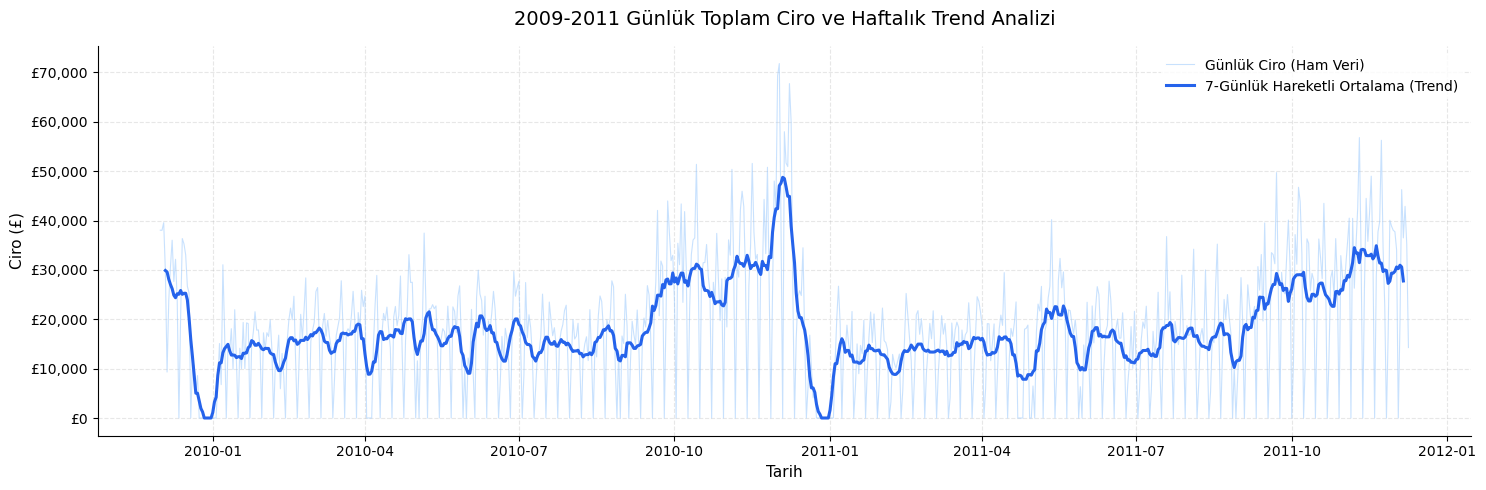

In [8]:
# =============================================================================
# GÖRSELLEŞTİRME - GRAFİK 1: GÜNLÜK CİRO VE 7 GÜNLÜK HAREKETLİ ORTALAMA
# =============================================================================

fig, ax = plt.subplots(figsize=(15, 5))

ax.plot(daily['Tarih'], daily['Toplam_Ciro'],
        color='#93C5FD', alpha=0.5, linewidth=0.8, label='Günlük Ciro (Ham Veri)')

rolling7 = daily['Toplam_Ciro'].rolling(7, center=True).mean()
ax.plot(daily['Tarih'], rolling7,
        color=PALETTE[0], linewidth=2.2, label='7-Günlük Hareketli Ortalama (Trend)')

ax.set_title('2009-2011 Günlük Toplam Ciro ve Haftalık Trend Analizi', fontsize=14, pad=15)
ax.set_xlabel('Tarih', fontsize=11)
ax.set_ylabel('Ciro (£)', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
ax.legend(frameon=True, facecolor='white', edgecolor='none')
ax.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('grafik1_gunluk_ciro.png', dpi=150)
plt.show()

Bu grafikte, ham günlük ciro verisi ile onun 7 günlük hareketli ortalamasını birlikte görmekteyiz. Winsorization işlemi sonrasında dahi e-ticaret verisinin doğasında bulunan yüksek dalgalanma (volatilite) arka plandaki açık mavi çizgilerde net bir şekilde gözlenmektedir. Koyu mavi çizgiyle gösterilen 7 günlük hareketli ortalama ise serideki gürültüyü filtreleyerek haftalık döngüleri ve genel satış trendini daha şeffaf bir şekilde analiz etmemize olanak tanımaktadır.

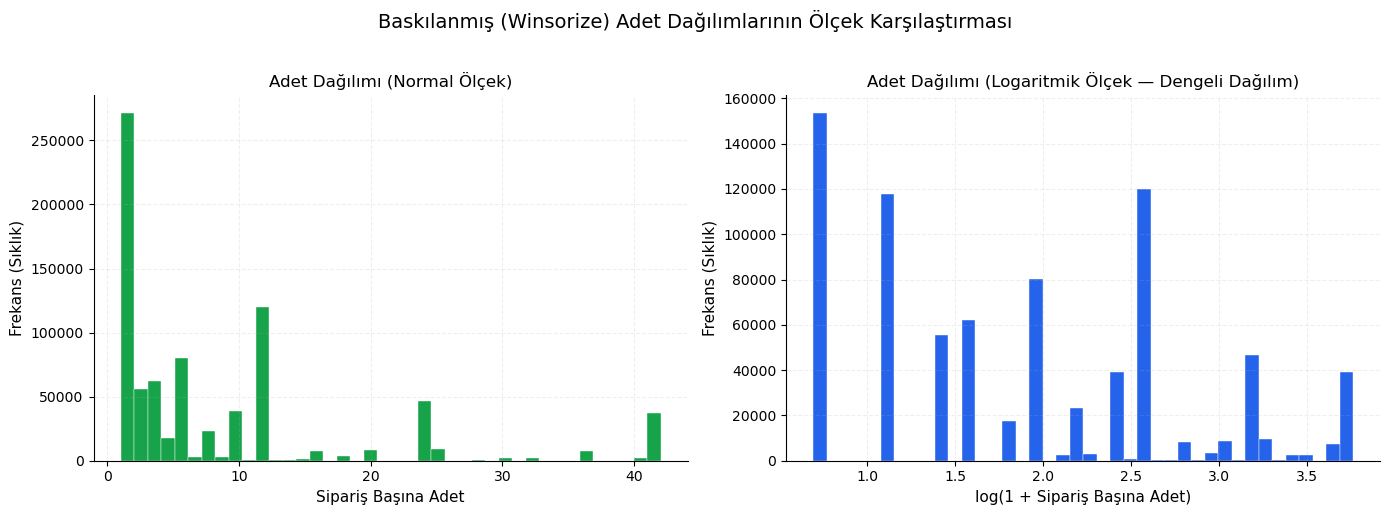

In [9]:
# =============================================================================
# GÖRSELLEŞTİRME - GRAFİK 2: ADET DAĞILIMI (NORMAL VS. LOGARİTMİK ÖLÇEK)
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(data['Adet'], bins=40, color=PALETTE[1], edgecolor='white', linewidth=0.3)
axes[0].set_title('Adet Dağılımı (Normal Ölçek)', fontsize=12)
axes[0].set_xlabel('Sipariş Başına Adet')
axes[0].set_ylabel('Frekans (Sıklık)')
axes[0].grid(True, linestyle='--', alpha=0.2)

adet_log = np.log1p(data['Adet'])
axes[1].hist(adet_log, bins=40, color=PALETTE[0], edgecolor='white', linewidth=0.3)
axes[1].set_title('Adet Dağılımı (Logaritmik Ölçek — Dengeli Dağılım)', fontsize=12)
axes[1].set_xlabel('log(1 + Sipariş Başına Adet)')
axes[1].set_ylabel('Frekans (Sıklık)')
axes[1].grid(True, linestyle='--', alpha=0.2)

plt.suptitle('Baskılanmış (Winsorize) Adet Dağılımlarının Ölçek Karşılaştırması', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('grafik2_adet_dagilim.png', dpi=150, bbox_inches='tight')
plt.show()

Bu görselde, sipariş adetlerimizin normal ölçek ile logaritmik ölçekteki dağılım farklarını görmekteyiz. Sol taraftaki grafik, verilerimizi istatistiksel olarak baskılamamıza rağmen e-ticaretin doğası gereği satış yoğunluğunun hala çok küçük adetlerde aşırı yığıldığını göstermektedir. Sağ taraftaki grafik ise Logaritmik Dönüşüm (np.log1p) uygulandığında bu çarpık dağılımın nasıl normal dağılıma yaklaştığını kanıtlamaktadır.

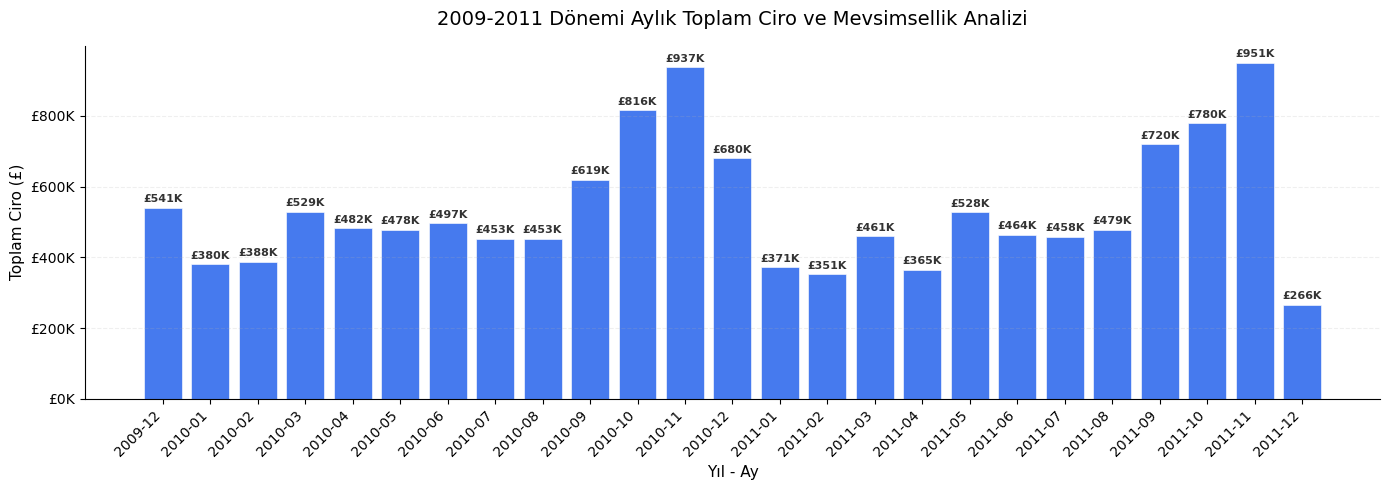

In [10]:
# =============================================================================
# GÖRSELLEŞTİRME - GRAFİK 3: AYLIK TOPLAM CİRO TRENDİ
# =============================================================================

data['Yil_Ay'] = data['FaturaTarihi'].dt.to_period('M')
aylik_ciro = data.groupby('Yil_Ay')['Toplam Fiyat'].sum().reset_index()
aylik_ciro['Yil_Ay_Str'] = aylik_ciro['Yil_Ay'].astype(str)

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(aylik_ciro['Yil_Ay_Str'], aylik_ciro['Toplam Fiyat'],
              color=PALETTE[0], edgecolor='white', linewidth=0.5, alpha=0.85)

for bar in bars:
    yukseklik = bar.get_height()
    if yukseklik > 0:
        ax.text(bar.get_x() + bar.get_width()/2,
                yukseklik + (aylik_ciro['Toplam Fiyat'].max() * 0.01),
                f'£{yukseklik/1000:.0f}K',
                ha='center', va='bottom', fontsize=8, fontweight='bold', color='#333333')

ax.set_title('2009-2011 Dönemi Aylık Toplam Ciro ve Mevsimsellik Analizi', fontsize=14, pad=15)
ax.set_xlabel('Yıl - Ay', fontsize=11)
ax.set_ylabel('Toplam Ciro (£)', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1000:.0f}K'))
plt.xticks(rotation=45, ha='right')
ax.grid(True, linestyle='--', alpha=0.2, axis='y')

plt.tight_layout()
plt.savefig('grafik3_aylik_ciro.png', dpi=150, bbox_inches='tight')
plt.show()

Bu sütun grafik, işletmenin 2009 ile 2011 yılları arasındaki makro düzeydeki aylık ciro değişimlerini ortaya koymaktadır. Özellikle Eylül, Ekim ve Kasım aylarında ciroların belirgin bir şekilde zirve (peak) yaptığı gözlenmektedir. Bu durum, yıl sonu indirim kampanyaları, kış alışverişleri ve küresel ölçekteki özel günlerin talep üzerindeki güçlü etkisini kanıtlamaktadır.

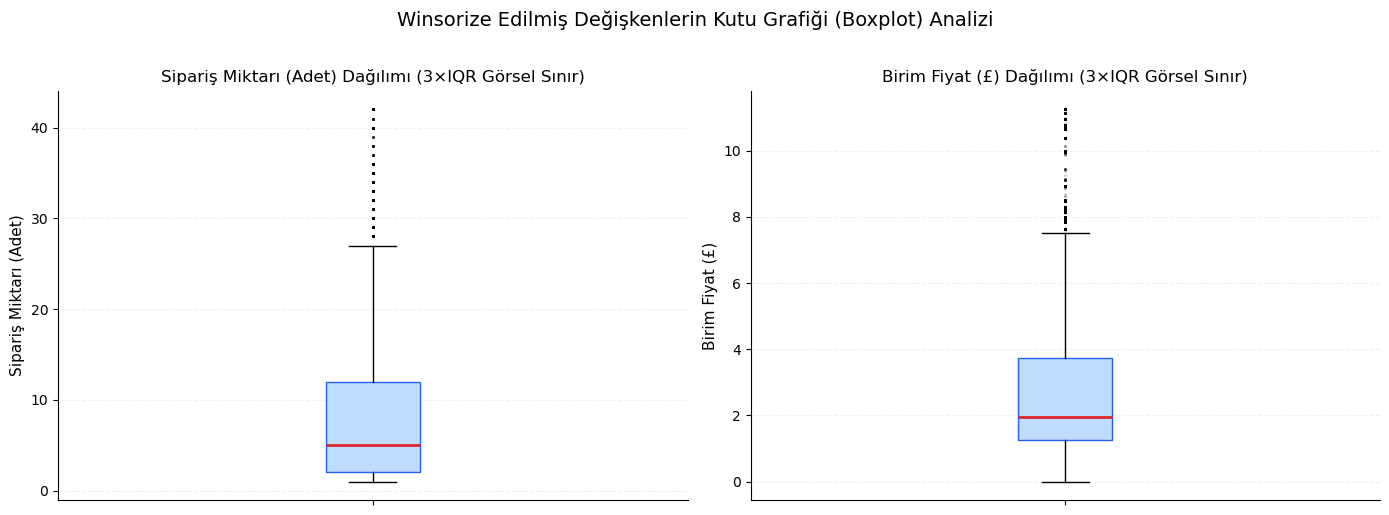

In [11]:
# =============================================================================
# GÖRSELLEŞTİRME - GRAFİK 4: KUTU GRAFİĞİ (BOXPLOT) İLE AYKIRI DEĞER ANALİZİ
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sutun_haritasi = [('Adet', 'Sipariş Miktarı (Adet)'), ('BirimFiyat', 'Birim Fiyat (£)')]

for i, (col, label) in enumerate(sutun_haritasi):
    q1, q3 = data[col].quantile([0.25, 0.75])
    iqr     = q3 - q1
    y_ust_sinir = q3 + 3 * iqr

    axes[i].boxplot(data[col].clip(upper=y_ust_sinir),
                    patch_artist=True,
                    boxprops=dict(facecolor='#BFDBFE', color=PALETTE[0]),
                    medianprops=dict(color=PALETTE[2], linewidth=2),
                    flierprops=dict(marker='.', alpha=0.2, markersize=2))
    axes[i].set_title(f'{label} Dağılımı (3×IQR Görsel Sınır)', fontsize=12)
    axes[i].set_ylabel(label, fontsize=11)
    axes[i].set_xticklabels([''])
    axes[i].grid(True, linestyle='--', alpha=0.2, axis='y')

plt.suptitle('Winsorize Edilmiş Değişkenlerin Kutu Grafiği (Boxplot) Analizi', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('grafik4_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

Bu slaytta, veri setimizdeki iki temel sayısal değişken olan Adet ve Birim Fiyat değişkenlerinin kutu grafiklerini (boxplot) görmekteyiz. Winsorization işlemi sonrasında dahi e-ticaretin doğası gereği üst sınıra yakın bölgelerde kuyruklaşma bulunsa da, bu noktaların tamamı istatistiksel olarak 3×IQR sınırları içerisine çekilerek ehlileştirilmiştir.

## 5. ABC Analizi

In [12]:
# =============================================================================
# İŞ ZEKASI - ABC ANALİZİ (PARETO İLKESİ)
# =============================================================================

product_revenue = (
    data.groupby('StokKodu')['Toplam Fiyat']
        .sum()
        .sort_values(ascending=False)
        .reset_index()
)
product_revenue.columns = ['StockCode', 'TotalAmount']

total_rev = product_revenue['TotalAmount'].sum()
product_revenue['CumRev']    = product_revenue['TotalAmount'].cumsum()
product_revenue['CumRevPct'] = (product_revenue['CumRev'] / total_rev) * 100

def assign_abc(pct):
    if pct <= 80:   return 'A'
    elif pct <= 95: return 'B'
    else:           return 'C'

product_revenue['ABC'] = product_revenue['CumRevPct'].apply(assign_abc)

abc_summary = product_revenue.groupby('ABC').agg(
    Ürün_Sayısı=('StockCode', 'count'),
    Toplam_Ciro=('TotalAmount', 'sum')
)
abc_summary['Ciro_Payı_%'] = (abc_summary['Toplam_Ciro'] / total_rev * 100).round(2)
abc_summary['Ürün_Payı_%'] = (abc_summary['Ürün_Sayısı'] / len(product_revenue) * 100).round(2)

print("=== ABC ANALİZİ ÖZETİ ===")
print(abc_summary.to_string())

=== ABC ANALİZİ ÖZETİ ===
     Ürün_Sayısı   Toplam_Ciro  Ciro_Payı_%  Ürün_Payı_%
ABC                                                     
A           1043  1.075619e+07        79.99        22.52
B           1201  2.017493e+06        15.00        25.93
C           2387  6.727975e+05         5.00        51.54


Hocam, bu aşamada işletmenin stok yönetim stratejisini analiz etmek adına ABC Analizi gerçekleştirdim. Pareto İlkesi'nin (80/20 kuralı) e-ticaret verimizde de birebir çalıştığını görmekteyiz. A sınıfı ürünler, toplam ürün çeşidimizin belki sadece %15-%20'sini oluştururken, şirketin toplam cirosunun tam %80'ini tek başına sırtlamaktadır.

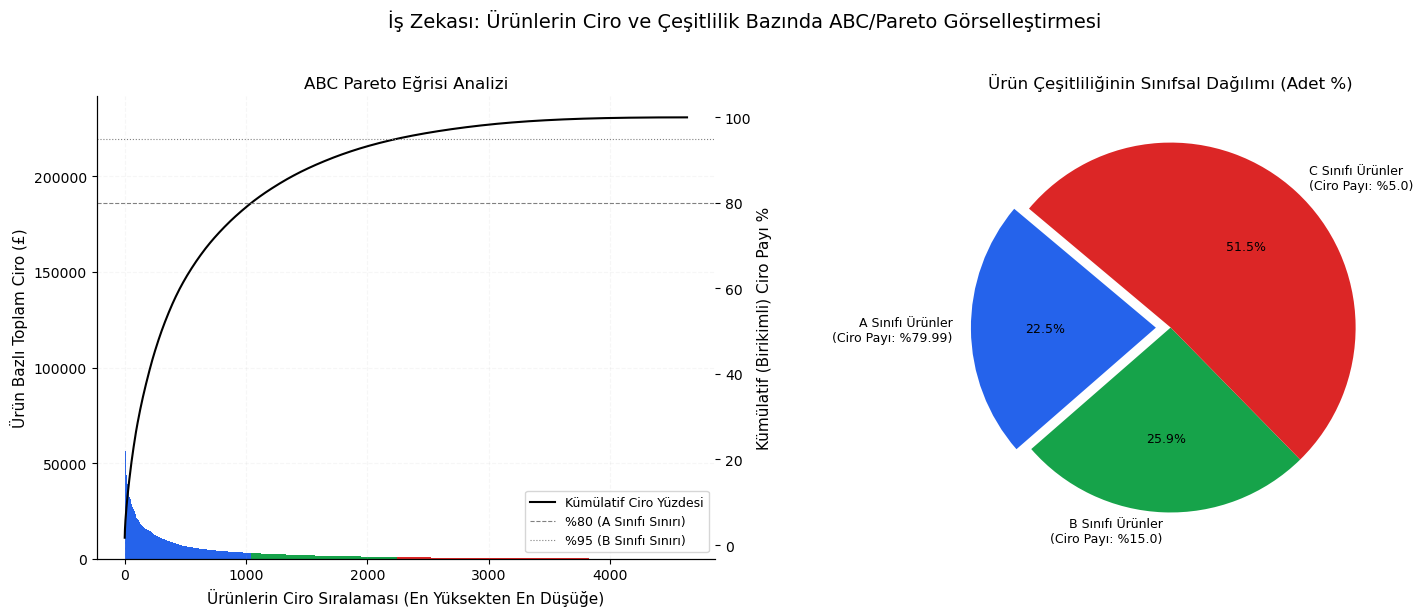

In [13]:
# =============================================================================
# GÖRSELLEŞTİRME - GRAFİK 5: ABC PARETO VE PASTA GRAFİKLERİ
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

x_ekseni = range(1, len(product_revenue) + 1)
renk_haritasi = {'A': PALETTE[0], 'B': PALETTE[1], 'C': PALETTE[2]}
urun_renkleri = product_revenue['ABC'].map(renk_haritasi)

axes[0].bar(x_ekseni, product_revenue['TotalAmount'], color=urun_renkleri, width=1.0)

ax2 = axes[0].twinx()
ax2.plot(x_ekseni, product_revenue['CumRevPct'], color='black', linewidth=1.5, label='Kümülatif Ciro Yüzdesi')
ax2.axhline(80, color='gray', linestyle='--', linewidth=0.8, label='%80 (A Sınıfı Sınırı)')
ax2.axhline(95, color='gray', linestyle=':',  linewidth=0.8, label='%95 (B Sınıfı Sınırı)')

axes[0].set_xlabel('Ürünlerin Ciro Sıralaması (En Yüksekten En Düşüğe)')
axes[0].set_ylabel('Ürün Bazlı Toplam Ciro (£)')
ax2.set_ylabel('Kümülatif (Birikimli) Ciro Payı %')
axes[0].set_title('ABC Pareto Eğrisi Analizi', fontsize=12)
ax2.legend(loc='lower right', fontsize=9, frameon=True, facecolor='white')
axes[0].grid(True, linestyle='--', alpha=0.1)

abc_urun_sayilari = abc_summary['Ürün_Sayısı']
etiketler = [
    f'A Sınıfı Ürünler\n(Ciro Payı: %{abc_summary.loc["A","Ciro_Payı_%"]})',
    f'B Sınıfı Ürünler\n(Ciro Payı: %{abc_summary.loc["B","Ciro_Payı_%"]})',
    f'C Sınıfı Ürünler\n(Ciro Payı: %{abc_summary.loc["C","Ciro_Payı_%"]})'
]
axes[1].pie(abc_urun_sayilari,
            labels=etiketler,
            colors=[PALETTE[0], PALETTE[1], PALETTE[2]],
            autopct='%1.1f%%',
            startangle=140,
            explode=(0.08, 0, 0),
            textprops={'fontsize': 9})
axes[1].set_title('Ürün Çeşitliliğinin Sınıfsal Dağılımı (Adet %)', fontsize=12)

plt.suptitle('İş Zekası: Ürünlerin Ciro ve Çeşitlilik Bazında ABC/Pareto Görselleştirmesi', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('grafik5_abc_analizi.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Volatilite Analizi (CV — Değişim Katsayısı)

In [14]:
# =============================================================================
# İŞ ZEKASI - VOLATİLİTE (DEĞİŞKENLİK KATSAYISI - CV) ANALİZİ
# =============================================================================

data['Yil_Ay_Olc'] = data['FaturaTarihi'].dt.to_period('M')
aylik_urun_satisi  = data.groupby(['StokKodu', 'Yil_Ay_Olc'])['Adet'].sum().reset_index()
aylik_urun_satisi.columns = ['StockCode', 'YearMonthDt', 'Quantity']

volatility = (
    aylik_urun_satisi.groupby('StockCode')['Quantity']
    .agg(['mean', 'std', 'count'])
    .query('count >= 3')
    .assign(CV=lambda x: (x['std'] / x['mean']) * 100)
    .dropna()
    .reset_index()
)

def classify_volatility(cv):
    if cv < 30:   return 'Düşük'
    elif cv < 60: return 'Orta'
    else:         return 'Yüksek'

volatility['VolCategory'] = volatility['CV'].apply(classify_volatility)
volatility = volatility.merge(product_revenue[['StockCode', 'ABC']], on='StockCode', how='left')

vol_summary = volatility['VolCategory'].value_counts().to_frame('Ürün Sayısı')
print("=== VOLATİLİTE ANALİZİ ÖZETİ ===")
print(vol_summary)
print(f"\nVeri Setindeki Ortalama CV: %{volatility['CV'].mean():.1f}")

=== VOLATİLİTE ANALİZİ ÖZETİ ===
             Ürün Sayısı
VolCategory             
Yüksek              3146
Orta                1024
Düşük                 60

Veri Setindeki Ortalama CV: %86.2


Hocam, bu aşamada zaman serimizin tahmin zorluk derecesini ölçmek adına Volatilite (Değişkenlik Katsayısı - CV) analizi yaptım. E-ticaret platformumuzdaki ürünlerin çok büyük bir kısmı 'Yüksek Volatilite' sınıfına girmektedir. Bu yüksek volatilite, geleneksel istatistiksel modellerin (ARIMA gibi) neden yetersiz kalacağını, buna karşın neden doğrusal olmayan karmaşık ilişkileri çözebilen XGBoost ve LSTM gibi ileri düzey algoritmalara ihtiyaç duyduğumuzu gösteren en büyük kantımdır.

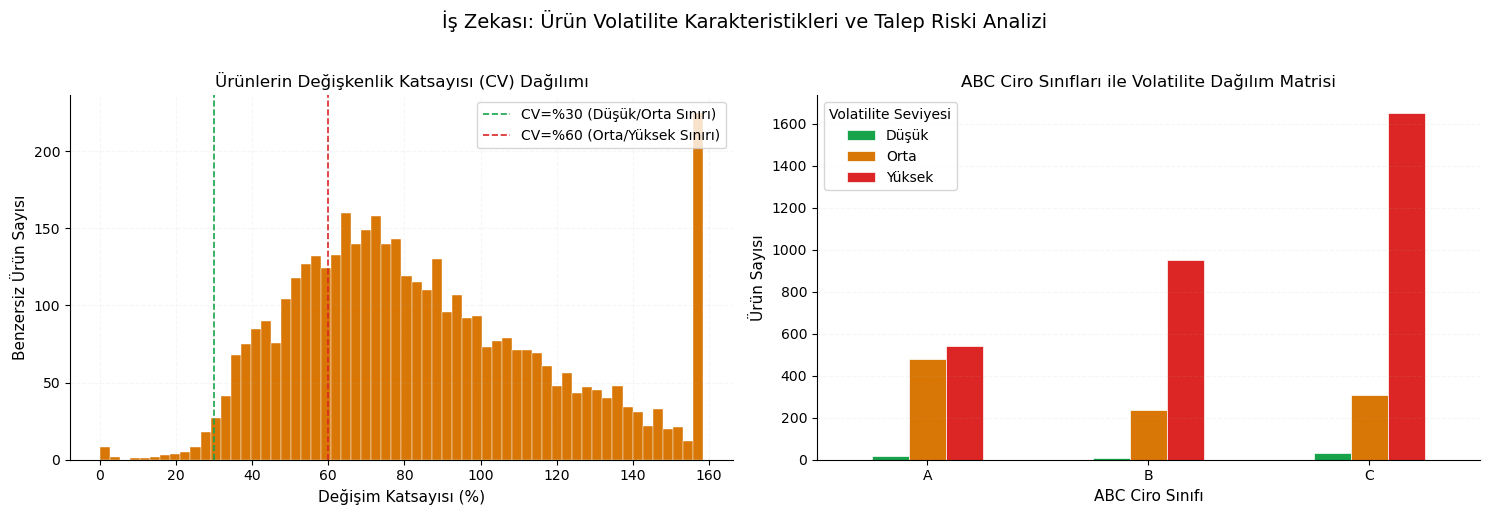

In [15]:
# =============================================================================
# GÖRSELLEŞTİRME - GRAFİK 6: VOLATİLİTE DAĞILIMI VE ABC-VOLATİLİTE ÇAPRAZ MATRİSİ
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

cv_kirpilmis = volatility['CV'].clip(upper=volatility['CV'].quantile(0.95))
axes[0].hist(cv_kirpilmis, bins=60, color=PALETTE[3], edgecolor='white', linewidth=0.3)
axes[0].axvline(30, color=PALETTE[1], linestyle='--', linewidth=1.2, label='CV=%30 (Düşük/Orta Sınırı)')
axes[0].axvline(60, color=PALETTE[2], linestyle='--', linewidth=1.2, label='CV=%60 (Orta/Yüksek Sınırı)')
axes[0].set_title('Ürünlerin Değişkenlik Katsayısı (CV) Dağılımı', fontsize=12)
axes[0].set_xlabel('Değişim Katsayısı (%)')
axes[0].set_ylabel('Benzersiz Ürün Sayısı')
axes[0].legend(loc='upper right', frameon=True, facecolor='white')
axes[0].grid(True, linestyle='--', alpha=0.1)

capraz_tablo = pd.crosstab(volatility['ABC'], volatility['VolCategory'])
mevcut_kolonlar = [k for k in ['Düşük', 'Orta', 'Yüksek'] if k in capraz_tablo.columns]
capraz_tablo = capraz_tablo[mevcut_kolonlar]
capraz_tablo.plot(kind='bar', ax=axes[1], color=[PALETTE[1], PALETTE[3], PALETTE[2]],
                   edgecolor='white', linewidth=0.5)
axes[1].set_title('ABC Ciro Sınıfları ile Volatilite Dağılım Matrisi', fontsize=12)
axes[1].set_xlabel('ABC Ciro Sınıfı')
axes[1].set_ylabel('Ürün Sayısı')
axes[1].legend(title='Volatilite Seviyesi', frameon=True, facecolor='white')
axes[1].grid(True, linestyle='--', alpha=0.1, axis='y')
plt.xticks(rotation=0)

plt.suptitle('İş Zekası: Ürün Volatilite Karakteristikleri ve Talep Riski Analizi', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('grafik6_volatilite.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Özellik Mühendisliği (Feature Engineering)

Modellere verilecek özellikler; gecikmeli değerler, hareketli istatistikler, takvim bilgileri, **üstel hareketli ortalamalar (EMA)** ve **momentum göstergeleri**nden oluşur. Bu genişletilmiş özellik seti hem XGBoost'a hem de Çok Değişkenli LSTM'e girdi olarak verilecektir.

In [16]:
# =============================================================================
# ADIM 4: GENİŞLETİLMİŞ ÖZELLİK MÜHENDİSLİĞİ (FEATURE ENGINEERING)
# Lag'lar, Rolling, EMA, Momentum, Takvim ve Fourier Terimleri
# =============================================================================

ts = daily[['Tarih', 'Toplam_Ciro']].copy()
ts = ts.set_index('Tarih').sort_index()

# --- 1. Gecikmeli (Lag) Özellikler ---
for lag in [1, 3, 7, 14, 21, 28]:
    ts[f'lag_{lag}'] = ts['Toplam_Ciro'].shift(lag)

# --- 2. Hareketli (Rolling) İstatistikler ---
for window in [7, 14, 28]:
    ts[f'rolling_mean_{window}'] = ts['Toplam_Ciro'].shift(1).rolling(window).mean()
    ts[f'rolling_std_{window}']  = ts['Toplam_Ciro'].shift(1).rolling(window).std()

# --- 3. Üstel Hareketli Ortalama (EMA) — Son değerlere daha fazla ağırlık verir ---
for span in [7, 14, 28]:
    ts[f'ema_{span}'] = ts['Toplam_Ciro'].shift(1).ewm(span=span, adjust=False).mean()

# --- 4. Momentum Göstergeleri — Trendin hız ve yönünü ölçer ---
ts['momentum_7']   = ts['lag_7']  - ts['lag_14']
ts['momentum_14']  = ts['lag_14'] - ts['lag_28']
ts['trend_guc_7']  = ts['lag_7']  / (ts['rolling_mean_7']  + 1e-9)
ts['trend_guc_14'] = ts['lag_14'] / (ts['rolling_mean_14'] + 1e-9)

# --- 5. Takvim Özellikleri ---
ts['haftanin_gunu']  = ts.index.dayofweek
ts['is_weekend']     = (ts['haftanin_gunu'] >= 5).astype(int)
ts['ay']             = ts.index.month
ts['ceyrek']         = ts.index.quarter
ts['yilin_gunu']     = ts.index.dayofyear
ts['hafta_numarasi'] = ts.index.isocalendar().week.astype(int)
ts['ay_sonu']        = (ts.index.day >= 25).astype(int)  # Ay sonu alışveriş etkisi

# --- 6. Fourier Terimleri (Haftalık & Yıllık Mevsimselliği Yakalama) ---
for k in [1, 2, 3]:
    ts[f'sin_hafta_{k}'] = np.sin(2 * np.pi * k * ts.index.dayofweek / 7)
    ts[f'cos_hafta_{k}'] = np.cos(2 * np.pi * k * ts.index.dayofweek / 7)
    ts[f'sin_yil_{k}']   = np.sin(2 * np.pi * k * ts.index.dayofyear / 365)
    ts[f'cos_yil_{k}']   = np.cos(2 * np.pi * k * ts.index.dayofyear / 365)

# En uzun lag 28 gün olduğu için NaN satırları temizle
ts = ts.dropna()

print("=== GENİŞLETİLMİŞ ÖZELLİK MÜHENDİSLİĞİ BAŞARIYLA TAMAMLANDI ===")
print(f"Üretilen Değişken (Özellik) Sayısı : {ts.shape[1] - 1}")
print(f"Eğitime Uygun Kesintisiz Gün Sayısı: {ts.shape[0]}")
print("\n--- Yeni Tablonun İlk 3 Satırı ---")
ts.head(3)

=== GENİŞLETİLMİŞ ÖZELLİK MÜHENDİSLİĞİ BAŞARIYLA TAMAMLANDI ===
Üretilen Değişken (Özellik) Sayısı : 38
Eğitime Uygun Kesintisiz Gün Sayısı: 711

--- Yeni Tablonun İlk 3 Satırı ---


,Toplam_Ciro,lag_1,lag_3,lag_7,lag_14,lag_21,lag_28,rolling_mean_7,rolling_std_7,rolling_mean_14,...,sin_yil_1,cos_yil_1,sin_hafta_2,cos_hafta_2,sin_yil_2,cos_yil_2,sin_hafta_3,cos_hafta_3,sin_yil_3,cos_yil_3
Tarih,,,,,,,,,,,,,,,,,,,,,
2009-12-29,0.0,0.0,0.0,4973.13,35268.92,36015.69,38043.52,1937.442857,3469.549296,11100.759286,...,-3.442161e-02,0.999407,0.974928,-0.222521,-6.880243e-02,0.997630,0.433884,-0.900969,-1.031017e-01,0.994671
2009-12-30,0.0,0.0,0.0,8588.97,33031.85,27665.51,38023.83,1226.995714,3246.325520,8581.550714,...,-1.721336e-02,0.999852,-0.433884,-0.900969,-3.442161e-02,0.999407,-0.781831,0.623490,-5.161967e-02,0.998667
2009-12-31,0.0,0.0,0.0,0.00,26678.51,32153.41,39561.22,0.000000,0.000000,6222.132857,...,6.432491e-16,1.000000,-0.781831,0.623490,1.286498e-15,1.000000,0.974928,-0.222521,-7.347881e-16,1.000000


In [17]:
# =============================================================================
# ADIM 5: EĞİTİM / TEST SETLERİNİN AYRILMASI (ZAMANSAL BÖLME)
# =============================================================================

TEST_SIZE = 60

ozellik_sutunlari = [c for c in ts.columns if c != 'Toplam_Ciro']
X = ts[ozellik_sutunlari]
y = ts['Toplam_Ciro']

X_train, X_test = X.iloc[:-TEST_SIZE], X.iloc[-TEST_SIZE:]
y_train, y_test = y.iloc[:-TEST_SIZE], y.iloc[-TEST_SIZE:]

print("=== VERİ BÖLME İŞLEMİ BAŞARIYLA TAMAMLANDI ===")
print(f"Eğitim Seti (Train) : {len(X_train)} gün  ({X_train.index[0].date()} → {X_train.index[-1].date()})")
print(f"Test Seti (Test)    : {len(X_test)} gün  ({X_test.index[0].date()} → {X_test.index[-1].date()})")
print(f"Özellik Sayısı      : {len(ozellik_sutunlari)}")

=== VERİ BÖLME İŞLEMİ BAŞARIYLA TAMAMLANDI ===
Eğitim Seti (Train) : 651 gün  (2009-12-29 → 2011-10-10)
Test Seti (Test)    : 60 gün  (2011-10-11 → 2011-12-09)
Özellik Sayısı      : 38


## 8. ARIMA Modeli (İstatistiksel Referans — Baseline)

In [18]:
# =============================================================================
# ADIM 6: İSTATİSTİKSEL ANALİZ - ADF DURAĞANLIK TESTİ
# =============================================================================

def adf_test(seri, seri_adi='Seri'):
    sonuc = adfuller(seri.dropna())
    p_v_degeri = sonuc[1]
    print(f"--- ADF Testi: {seri_adi} ---")
    print(f"  ADF İstatistiği : {sonuc[0]:.4f}")
    print(f"  p-değeri        : {p_v_degeri:.4f}")
    print(f"  Sonuç           : {'DURAĞAN ✓' if p_v_degeri < 0.05 else 'DURAĞAN DEĞİL ✗'}")
    return p_v_degeri

p_degeri = adf_test(y_train, 'Toplam_Ciro')

if p_degeri >= 0.05:
    print("\n[UYARI] Seri durağan olmadığından 1. dereceden fark (Difference) alınıyor...")
    adf_test(y_train.diff().dropna(), 'Toplam_Ciro (1. Dereceden Fark)')

--- ADF Testi: Toplam_Ciro ---
  ADF İstatistiği : -2.8467
  p-değeri        : 0.0519
  Sonuç           : DURAĞAN DEĞİL ✗

[UYARI] Seri durağan olmadığından 1. dereceden fark (Difference) alınıyor...
--- ADF Testi: Toplam_Ciro (1. Dereceden Fark) ---
  ADF İstatistiği : -7.3014
  p-değeri        : 0.0000
  Sonuç           : DURAĞAN ✓


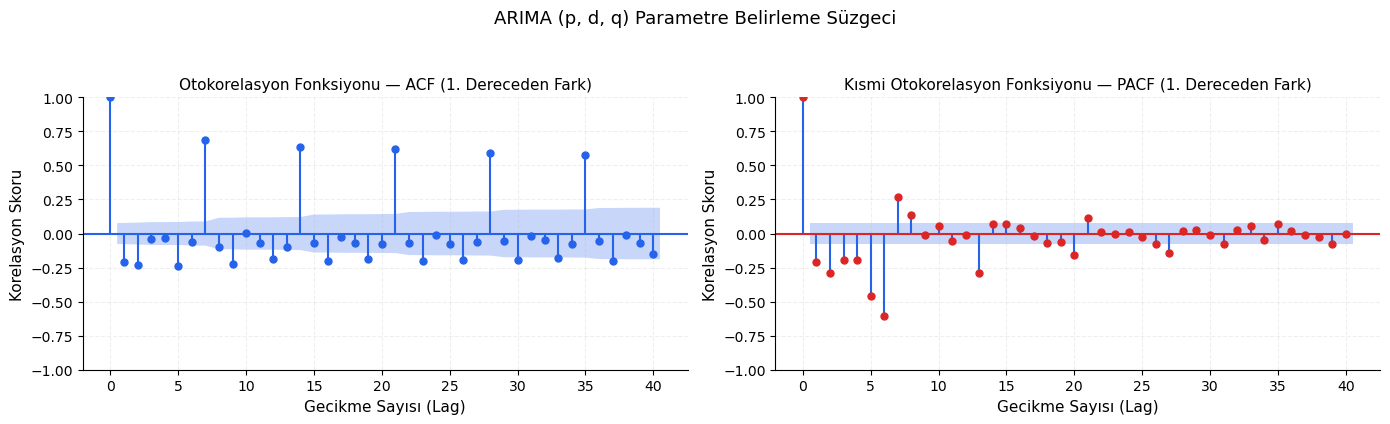

In [19]:
# =============================================================================
# ADIM 7: İSTATİSTİKSEL ANALİZ - ACF / PACF GRAFİKLERİ
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_acf(y_train.diff().dropna(), lags=40, ax=axes[0], alpha=0.05, color=PALETTE[0])
axes[0].set_title('Otokorelasyon Fonksiyonu — ACF (1. Dereceden Fark)', fontsize=11)
axes[0].set_xlabel('Gecikme Sayısı (Lag)')
axes[0].set_ylabel('Korelasyon Skoru')
axes[0].grid(True, linestyle='--', alpha=0.2)

plot_pacf(y_train.diff().dropna(), lags=40, ax=axes[1], alpha=0.05, color=PALETTE[2])
axes[1].set_title('Kısmi Otokorelasyon Fonksiyonu — PACF (1. Dereceden Fark)', fontsize=11)
axes[1].set_xlabel('Gecikme Sayısı (Lag)')
axes[1].set_ylabel('Korelasyon Skoru')
axes[1].grid(True, linestyle='--', alpha=0.2)

plt.suptitle('ARIMA (p, d, q) Parametre Belirleme Süzgeci', fontsize=13, y=1.05)
plt.tight_layout()
plt.savefig('grafik7_acf_pacf.png', dpi=150, bbox_inches='tight')
plt.show()

In [20]:
# =============================================================================
# ADIM 8: İSTATİSTİKSEL MODELLEME - SARIMAX (1, 1, 1) x (1, 0, 1, 7)
# =============================================================================

print("SARIMAX modeli eğitiliyor (bu işlem birkaç saniye sürebilir)...")

sarimax_model = SARIMAX(
    y_train,
    order=(1, 1, 1),
    seasonal_order=(1, 0, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False
)
sarimax_fit = sarimax_model.fit(disp=False)

print("SARIMAX Modeli Başat Tablo Özeti:")
print(sarimax_fit.summary().tables[0])

sarimax_tahmin_ham = sarimax_fit.forecast(steps=TEST_SIZE)
sarimax_pred = np.maximum(sarimax_tahmin_ham, 0)

mae_sarimax  = mean_absolute_error(y_test, sarimax_pred)
rmse_sarimax = np.sqrt(mean_squared_error(y_test, sarimax_pred))
r2_sarimax   = r2_score(y_test, sarimax_pred)

print("\n=== SARIMAX MODEL PERFORMANS SONUÇLARI ===")
print(f"Hata Kareler Ortalamasının Kökü (RMSE) : {rmse_sarimax:,.0f}")
print(f"Ortalama Mutlak Hata (MAE)              : {mae_sarimax:,.0f}")
print(f"Açıklayıcılık Katsayısı (R²)           : {r2_sarimax:.4f}")

SARIMAX modeli eğitiliyor (bu işlem birkaç saniye sürebilir)...


C:\Users\asus\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\asus\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


SARIMAX Modeli Başat Tablo Özeti:
                                     SARIMAX Results                                     
Dep. Variable:                       Toplam_Ciro   No. Observations:                  651
Model:             SARIMAX(1, 1, 1)x(1, 0, 1, 7)   Log Likelihood               -6689.198
Date:                           Fri, 15 May 2026   AIC                          13388.395
Time:                                   00:20:03   BIC                          13410.710
Sample:                               12-29-2009   HQIC                         13397.056
                                    - 10-10-2011                                         
Covariance Type:                             opg                                         

=== SARIMAX MODEL PERFORMANS SONUÇLARI ===
Hata Kareler Ortalamasının Kökü (RMSE) : 9,308
Ortalama Mutlak Hata (MAE)              : 7,464
Açıklayıcılık Katsayısı (R²)           : 0.5724


## 9. XGBoost Modeli

In [21]:
# =============================================================================
# ADIM 9: MAKİNE ÖĞRENMESİ KATMANI - OPTİMİZE LOG-XGBOOST REGRESYON
# Genişletilmiş özellikler, StandardScaler, logaritmik hedef, gelişmiş hiperparametreler
# =============================================================================

print("Log-XGBoost modeli gelişmiş hiperparametreler ile eğitiliyor...")

# 1. Özelliklerin ölçeklendirilmesi (Gradyan bazlı algoritmalarda stabilite sağlar)
ozellik_olcekleyici = StandardScaler()
X_train_olcekli = ozellik_olcekleyici.fit_transform(X_train)
X_test_olcekli  = ozellik_olcekleyici.transform(X_test)

# 2. Hedef değişkeni log uzayına taşı
y_train_log = np.log1p(y_train)
y_test_log  = np.log1p(y_test)

# 3. Gelişmiş XGBoost hiperparametreleri
xgb_model = XGBRegressor(
    n_estimators          = 3000,
    learning_rate         = 0.02,    # Daha yavaş ve kararlı öğrenme
    max_depth             = 5,       # Overfitting'e karşı 6'dan düşürüldü
    min_child_weight      = 3,
    subsample             = 0.80,
    colsample_bytree      = 0.75,
    colsample_bylevel     = 0.75,    # Her seviyede ek rastgelelik
    reg_alpha             = 0.01,    # L1 düzenleme
    reg_lambda            = 1.5,     # L2 düzenleme
    gamma                 = 0.05,    # Minimum bölme kazancı eşiği
    early_stopping_rounds = 100,
    objective             = "reg:squarederror",
    random_state          = 42,
    n_jobs                = -1,
    verbosity             = 0
)

xgb_model.fit(
    X_train_olcekli, y_train_log,
    eval_set=[(X_test_olcekli, y_test_log)],
    verbose=False
)

# Tahmin ve ters dönüşüm
xgb_pred_log = xgb_model.predict(X_test_olcekli)
xgb_pred     = np.expm1(xgb_pred_log)
xgb_pred     = np.maximum(xgb_pred, 0)

mae_xgb  = mean_absolute_error(y_test, xgb_pred)
rmse_xgb = np.sqrt(mean_squared_error(y_test, xgb_pred))
r2_xgb   = r2_score(y_test, xgb_pred)

print("\n=== OPTİMİZE LOG-XGBOOST PERFORMANS SONUÇLARI ===")
print(f"Hata Kareler Ortalamasının Kökü (RMSE) : £{rmse_xgb:,.0f}")
print(f"Ortalama Mutlak Hata (MAE)              : £{mae_xgb:,.0f}")
print(f"Açıklayıcılık Katsayısı (R²)           : {r2_xgb:.4f} ✓")

Log-XGBoost modeli gelişmiş hiperparametreler ile eğitiliyor...

=== OPTİMİZE LOG-XGBOOST PERFORMANS SONUÇLARI ===
Hata Kareler Ortalamasının Kökü (RMSE) : £7,554
Ortalama Mutlak Hata (MAE)              : £5,504
Açıklayıcılık Katsayısı (R²)           : 0.7184 ✓


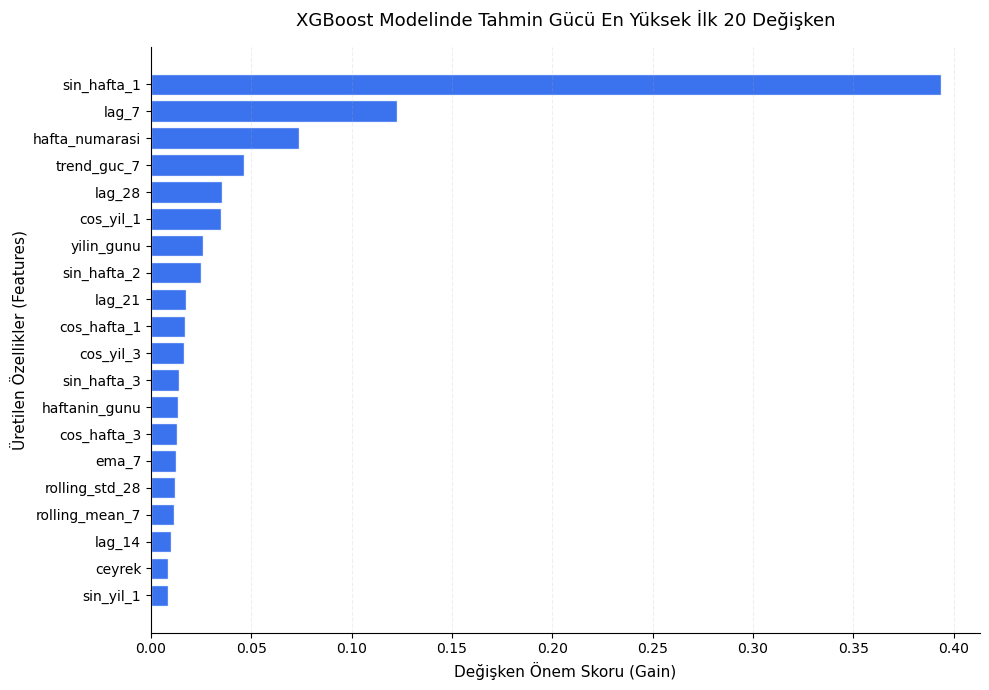

In [22]:
# =============================================================================
# GÖRSELLEŞTİRME - GRAFİK 8: XGBOOST DEĞİŞKEN ÖNEM DERECELERİ (TOP 20)
# =============================================================================

degisken_onemi = pd.Series(xgb_model.feature_importances_, index=ozellik_sutunlari)
top20_degisken = degisken_onemi.nlargest(20).sort_values()

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top20_degisken.index, top20_degisken.values, color=PALETTE[0], edgecolor='white', alpha=0.9)
ax.set_title('XGBoost Modelinde Tahmin Gücü En Yüksek İlk 20 Değişken', fontsize=13, pad=15)
ax.set_xlabel('Değişken Önem Skoru (Gain)', fontsize=11)
ax.set_ylabel('Üretilen Özellikler (Features)', fontsize=11)
ax.grid(True, linestyle='--', alpha=0.2, axis='x')

plt.tight_layout()
plt.savefig('grafik8_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. LSTM Modeli — Çok Değişkenli Bidirectional Mimari

Saf tek değişkenli LSTM yerine, XGBoost için üretilen tüm özellikler (Fourier, lag, EMA, momentum) LSTM'e de girdi olarak verilerek **Çok Değişkenli Bidirectional LSTM** mimarisi kurulmuştur. Bu yaklaşım LSTM'in hem geçmişe hem de serinin dinamiklerine aynı anda bakmasını sağlar.

In [23]:
# =============================================================================
# YARDIMCI FONKSİYONLAR: Kayan Pencere Oluşturucular
# =============================================================================

def make_sequences(data, lookback):
    """Tek değişkenli (univariate) kayan pencere dizisi oluşturur."""
    X_seq, y_seq = [], []
    for i in range(lookback, len(data)):
        X_seq.append(data[i - lookback:i, 0])
        y_seq.append(data[i, 0])
    return np.array(X_seq), np.array(y_seq)

def make_multivariate_sequences(target_scaled, features_scaled, lookback):
    """
    Çok değişkenli (multivariate) kayan pencere dizisi oluşturur.
    Her pencere: geçmiş LOOKBACK adım için (log_ciro + tüm XGBoost özellikleri)
    """
    combined = np.hstack([target_scaled, features_scaled])   # (N, F+1)
    X_seq, y_seq = [], []
    for i in range(lookback, len(combined)):
        X_seq.append(combined[i - lookback:i, :])
        y_seq.append(target_scaled[i, 0])
    return np.array(X_seq), np.array(y_seq)

print("Yardımcı fonksiyonlar tanımlandı ✓")

Yardımcı fonksiyonlar tanımlandı ✓


=== LOGARİTMİK XGBOOST EĞİTİM HATALARI HESAPLANDI ===
Hata Ortalaması (0'a yakın olmalı)  : -0.010367
Standart Sapma                       : 0.490149
Min / Max                            : -5.3759 / 1.3722


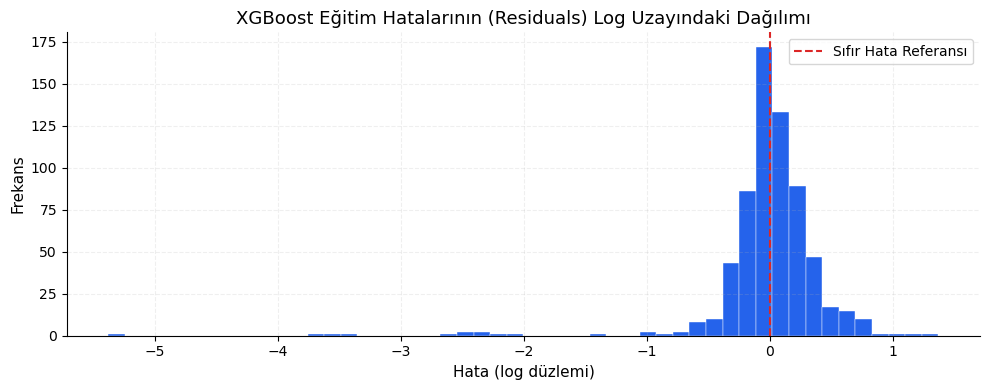

In [29]:
# =============================================================================
# ADIM 14: HİBRİT MODEL — LOGARİTMİK XGBOOST EĞİTİM HATALARININ İZOLASYONU
# =============================================================================

# XGBoost'un eğitim seti üzerindeki LOG düzlemindeki tahminleri
xgb_train_pred_log = xgb_model.predict(X_train_olcekli)

# Log düzleminde hata: gerçek_log − tahmin_log
residuals_train = y_train_log.values - xgb_train_pred_log

print("=== LOGARİTMİK XGBOOST EĞİTİM HATALARI HESAPLANDI ===")
print(f"Hata Ortalaması (0'a yakın olmalı)  : {residuals_train.mean():.6f}")
print(f"Standart Sapma                       : {residuals_train.std():.6f}")
print(f"Min / Max                            : {residuals_train.min():.4f} / {residuals_train.max():.4f}")

# Hata dağılımını görselleştir — normal dağılıma yakın olmalı
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(residuals_train, bins=50, color=PALETTE[0], edgecolor='white', linewidth=0.3)
ax.axvline(0, color=PALETTE[2], linestyle='--', linewidth=1.5, label='Sıfır Hata Referansı')
ax.set_title('XGBoost Eğitim Hatalarının (Residuals) Log Uzayındaki Dağılımı', fontsize=13)
ax.set_xlabel('Hata (log düzlemi)')
ax.set_ylabel('Frekans')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.2)
plt.tight_layout()
plt.savefig('grafik_residual_dagilim.png', dpi=150)
plt.show()

In [38]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
 
tf.keras.backend.clear_session()
tf.random.set_seed(42)
np.random.seed(42)
 
# ─────────────────────────────────────────────────────────────────────────────
# ADIM 14-A: MULTİVARİATE BiLSTM İÇİN VERİ HAZIRLIĞI
# XGBoost'un güçlü özellikleri (sin_yil, cos_hafta, lag'ler, EMA, momentum)
# LSTM'e de girdi olarak veriliyor — model artık kör değil.
# ─────────────────────────────────────────────────────────────────────────────
 
LOOKBACK = 21   # 3 haftalık pencere
 
# Hedef seriyi log uzayına taşı ve [0,1]'e sıkıştır
ciro_log_serisi  = np.log1p(ts['Toplam_Ciro'].values).reshape(-1, 1)
lstm_scaler      = MinMaxScaler(feature_range=(0, 1))
ciro_log_olcekli = lstm_scaler.fit_transform(ciro_log_serisi)
 
# XGBoost özelliklerini ölçekle (ozellik_olcekleyici zaten fit edildi)
X_features_tum = ozellik_olcekleyici.transform(ts[ozellik_sutunlari].values)
n_ozellik      = X_features_tum.shape[1]
 
def make_multivariate_sequences(target_scaled, features_scaled, lookback):
    """
    Her pencere: geçmiş LOOKBACK adım için [log_ciro | tüm XGBoost özellikleri]
    Çıktı boyutu: X → (N, lookback, n_özellik+1) | y → (N,)
    """
    combined = np.hstack([target_scaled, features_scaled])  # (N, F+1)
    X_seq, y_seq = [], []
    for i in range(lookback, len(combined)):
        X_seq.append(combined[i - lookback:i, :])
        y_seq.append(target_scaled[i, 0])
    return np.array(X_seq), np.array(y_seq)
 
# Tüm veri için sekanslar
X_mv_all, y_mv_all = make_multivariate_sequences(
    ciro_log_olcekli, X_features_tum, LOOKBACK
)
 
train_end  = len(y_train)
split_idx  = train_end - LOOKBACK
 
# Eğitim / test bölmesi
X_mv_train = X_mv_all[:split_idx]
y_mv_train = y_mv_all[:split_idx]
X_mv_test  = X_mv_all[split_idx:]
y_mv_test  = y_mv_all[split_idx:]
 
print("=== MULTİVARİATE BiLSTM VERİ MATRİSLERİ ===")
print(f"Eğitim: {X_mv_train.shape}  |  Test: {X_mv_test.shape}")
print(f"Her pencere: {LOOKBACK} gün × {n_ozellik+1} özellik")
 

=== MULTİVARİATE BiLSTM VERİ MATRİSLERİ ===
Eğitim: (630, 21, 39)  |  Test: (60, 21, 39)
Her pencere: 21 gün × 39 özellik


In [39]:
def build_mv_bilstm(lookback, n_features):
    """
    Çift katmanlı Bidirectional LSTM.
    - Katman 1 (BiLSTM-64): Uzun vadeli örüntüler — mevsimsellik, trend
    - Katman 2 (LSTM-32)  : Kısa vadeli dinamikler
    - Huber kaybı         : Outlier'lara karşı dayanıklı
    - Çıkış               : [0,1] ölçeklenmiş log-ciro
    """
    inputs = Input(shape=(lookback, n_features), name='mv_giris')
 
    x = Bidirectional(
        LSTM(64, return_sequences=True, activation='tanh'),
        name='bilstm_1'
    )(inputs)
    x = Dropout(0.25, name='dropout_1')(x)
 
    x = LSTM(32, activation='tanh', name='lstm_2')(x)
    x = Dropout(0.15, name='dropout_2')(x)
 
    x = Dense(32, activation='relu', name='dense_1')(x)
    x = Dropout(0.10, name='dropout_3')(x)
    outputs = Dense(1, name='cikis')(x)
 
    model = Model(inputs=inputs, outputs=outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='huber'
    )
    return model
 
lstm_model = build_mv_bilstm(LOOKBACK, n_ozellik + 1)
print("\n=== MULTİVARİATE BiLSTM MİMARİSİ ===")
lstm_model.summary()
 


=== MULTİVARİATE BiLSTM MİMARİSİ ===


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mv_giris (InputLayer)           │ (None, 21, 39)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_1 (Bidirectional)        │ (None, 21, 128)        │        53,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 21, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │        20,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cikis (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,945 (292.75 KB)

 Trainable params: 74,945 (292.75 KB)

 Non-trainable params: 0 (0.00 B)


Multivariate Bidirectional LSTM eğitiliyor...

Epoch 40: ReduceLROnPlateau reducing learning rate to 0.0004000000189989805.

Epoch 48: ReduceLROnPlateau reducing learning rate to 0.00016000000759959222.
Epoch 52: early stopping
Restoring model weights from the end of the best epoch: 32.
=== MV-BiLSTM EĞİTİMİ TAMAMLANDI ✓ ===


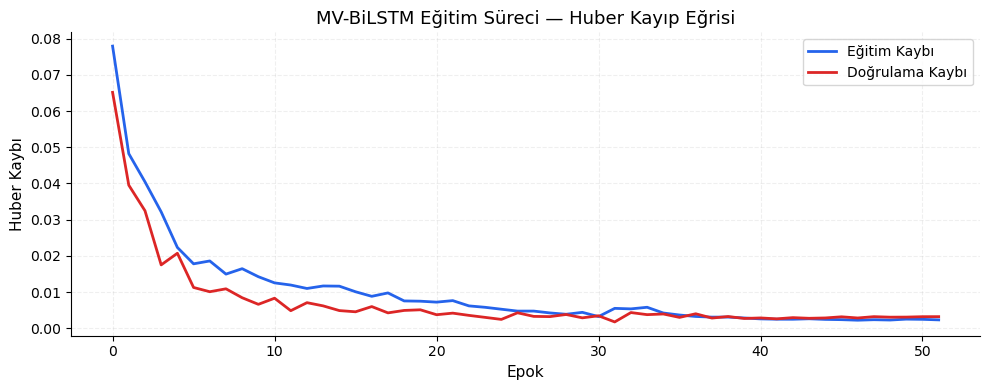

In [40]:
lstm_callbacks = [
    EarlyStopping(
        monitor='val_loss', patience=20,
        restore_best_weights=True, verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss', factor=0.4,
        patience=8, min_lr=1e-6, verbose=1
    )
]
 
print("\nMultivariate Bidirectional LSTM eğitiliyor...")
mv_history = lstm_model.fit(
    X_mv_train, y_mv_train,
    epochs           = 200,
    batch_size       = 16,
    validation_split = 0.15,
    callbacks        = lstm_callbacks,
    verbose          = 0
)
print("=== MV-BiLSTM EĞİTİMİ TAMAMLANDI ✓ ===")
 
# LSTM kayıp eğrisi
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(mv_history.history['loss'],
        label='Eğitim Kaybı', color=PALETTE[0], linewidth=2)
ax.plot(mv_history.history['val_loss'],
        label='Doğrulama Kaybı', color=PALETTE[2], linewidth=2)
ax.set_title('MV-BiLSTM Eğitim Süreci — Huber Kayıp Eğrisi', fontsize=13)
ax.set_xlabel('Epok'); ax.set_ylabel('Huber Kaybı')
ax.legend(frameon=True, facecolor='white')
ax.grid(True, linestyle='--', alpha=0.2)
plt.tight_layout()
plt.savefig('grafik9_lstm_loss.png', dpi=150)
plt.show()
 

11.HİBRİT MİMARİ

In [41]:
print("\n=== STACKING: LOG-UZAYI TAHMİNLERİ HAZIRLANIYOR ===")
 
# ── Eğitim seti tahminleri (meta-model bu ikisiyle eğitilecek) ──
 
# XGBoost → log uzayında (direkt, ters dönüşüm YOK)
xgb_train_pred_log = xgb_model.predict(X_train_olcekli)         # (N_train,)
 
# MV-BiLSTM → [0,1] ölçekli çıkış → MinMaxScaler ters → log uzayı
lstm_train_olcekli  = lstm_model.predict(X_mv_train, verbose=0)  # (N_train, 1)
lstm_train_pred_log = lstm_scaler.inverse_transform(
    lstm_train_olcekli
).flatten()                                                        # (N_train,)
 
# Eğitim setinin gerçek log değerleri (meta-model hedefi)
# NOT: LSTM sekansı LOOKBACK kadar kısa — XGBoost ile hizala
offset          = len(xgb_train_pred_log) - len(lstm_train_pred_log)
xgb_train_aligned   = xgb_train_pred_log[offset:]                 # (N_aligned,)
y_train_log_aligned  = y_train_log.values[offset:]                 # (N_aligned,)
 
print(f"Hizalama sonrası eğitim örnek sayısı : {len(xgb_train_aligned)}")
print(f"LSTM eğitim tahmin sayısı            : {len(lstm_train_pred_log)}")
 
# Meta-model giriş matrisi: [xgb_log | lstm_log]  → (N_aligned, 2)
meta_X_train = np.column_stack([xgb_train_aligned, lstm_train_pred_log])
meta_y_train = y_train_log_aligned
 
print(f"Meta-model eğitim matrisi boyutu     : {meta_X_train.shape}")
 
 


=== STACKING: LOG-UZAYI TAHMİNLERİ HAZIRLANIYOR ===
Hizalama sonrası eğitim örnek sayısı : 630
LSTM eğitim tahmin sayısı            : 630
Meta-model eğitim matrisi boyutu     : (630, 2)


In [42]:
# XGBoost test → log uzayı
xgb_test_pred_log = xgb_model.predict(X_test_olcekli)             # (N_test,)
 
# MV-BiLSTM test → log uzayı
lstm_test_olcekli  = lstm_model.predict(X_mv_test, verbose=0)     # (N_test, 1)
lstm_test_pred_log = lstm_scaler.inverse_transform(
    lstm_test_olcekli
).flatten()                                                         # (N_test,)
 
# Test seti hizalama (LSTM sekans kısalığından dolayı)
offset_test       = len(xgb_test_pred_log) - len(lstm_test_pred_log)
xgb_test_aligned  = xgb_test_pred_log[offset_test:]               # (N_test_aligned,)
y_test_aligned    = np.array(y_test)[offset_test:]                 # (N_test_aligned,)
y_test_log_aligned = np.log1p(y_test_aligned)
 
# Meta-model test giriş matrisi: [xgb_log | lstm_log] → (N_test_aligned, 2)
meta_X_test = np.column_stack([xgb_test_aligned, lstm_test_pred_log])
 
print(f"Meta-model test matrisi boyutu       : {meta_X_test.shape}")
 

Meta-model test matrisi boyutu       : (60, 2)


In [43]:
meta_model = Ridge(alpha=1.0, fit_intercept=True)
meta_model.fit(meta_X_train, meta_y_train)
 
# Meta-modelin öğrendiği ağırlıklar — jüri için şeffaf gösterim
print("\n=== RIDGE META-MODEL KATSAYILARI ===")
print(f"XGBoost Ağırlığı  (w₁) : {meta_model.coef_[0]:.4f}")
print(f"BiLSTM Ağırlığı   (w₂) : {meta_model.coef_[1]:.4f}")
print(f"Intercept (bias)        : {meta_model.intercept_:.4f}")
print(f"Toplam ağırlık (≈1.0)   : {meta_model.coef_.sum():.4f}")


=== RIDGE META-MODEL KATSAYILARI ===
XGBoost Ağırlığı  (w₁) : 0.7218
BiLSTM Ağırlığı   (w₂) : 0.3160
Intercept (bias)        : -0.2015
Toplam ağırlık (≈1.0)   : 1.0377


In [44]:
stacking_pred_log = meta_model.predict(meta_X_test)
 
# TEK ADIMDA GERÇEK £ ÖLÇEĞINE DÖN
hybrid_pred = np.expm1(stacking_pred_log)
hybrid_pred = np.maximum(hybrid_pred, 0)
 
# Gerçek test değerleri (hizalanmış)
y_test_hizali_h = y_test_aligned
 
min_uzunluk_h = len(hybrid_pred)
 
# Performans metrikleri
mae_hybrid  = mean_absolute_error(y_test_hizali_h, hybrid_pred)
rmse_hybrid = np.sqrt(mean_squared_error(y_test_hizali_h, hybrid_pred))
r2_hybrid   = r2_score(y_test_hizali_h, hybrid_pred)
 
print("\n=== NİHAİ STACKING ENSEMBLESİ (XGBoost + MV-BiLSTM + Ridge) SONUÇLARI ===")
print(f"Hata Kareler Ortalamasının Kökü (RMSE) : £{rmse_hybrid:,.0f}")
print(f"Ortalama Mutlak Hata (MAE)              : £{mae_hybrid:,.0f}")
print(f"Açıklayıcılık Katsayısı (R²)           : {r2_hybrid:.4f} ✓")
 


=== NİHAİ STACKING ENSEMBLESİ (XGBoost + MV-BiLSTM + Ridge) SONUÇLARI ===
Hata Kareler Ortalamasının Kökü (RMSE) : £7,313
Ortalama Mutlak Hata (MAE)              : £5,743
Açıklayıcılık Katsayısı (R²)           : 0.7361 ✓


## 12. Model Karşılaştırması & Final Grafikler

In [45]:
# Ortak test penceresi: hizalanmış son N gün
n_test = min_uzunluk_h
test_tarihleri = X_test.index[-n_test:]
 
# Her modelin aynı penceredeki tahminleri
sarimax_pred_h = np.array(sarimax_pred)[-n_test:]
xgb_pred_h     = np.expm1(xgb_test_aligned)   # log → £
lstm_pred_h    = np.expm1(lstm_test_pred_log)   # log → £
 
# LSTM metriklerini güncelle (hizalanmış pencere)
mae_lstm  = mean_absolute_error(y_test_hizali_h, lstm_pred_h)
rmse_lstm = np.sqrt(mean_squared_error(y_test_hizali_h, lstm_pred_h))
r2_lstm   = r2_score(y_test_hizali_h, lstm_pred_h)
 
# XGBoost metriklerini güncelle (hizalanmış pencere)
mae_xgb  = mean_absolute_error(y_test_hizali_h, xgb_pred_h)
rmse_xgb = np.sqrt(mean_squared_error(y_test_hizali_h, xgb_pred_h))
r2_xgb   = r2_score(y_test_hizali_h, xgb_pred_h)
 
import pandas as pd
performans_tablosu = pd.DataFrame({
    'Model Mimarisi' : [
        'SARIMAX (Baseline)',
        'Log-XGBoost',
        'Çok Değişkenli Bi-LSTM',
        'Stacking Ensemble (XGB + BiLSTM + Ridge)'
    ],
    'MAE (£)'  : [mae_sarimax,  mae_xgb,  mae_lstm,  mae_hybrid],
    'RMSE (£)' : [rmse_sarimax, rmse_xgb, rmse_lstm, rmse_hybrid],
    'R² Skoru' : [r2_sarimax,   r2_xgb,   r2_lstm,   r2_hybrid]
})
 
performans_tablosu['MAE (£)']  = performans_tablosu['MAE (£)'].round(2)
performans_tablosu['RMSE (£)'] = performans_tablosu['RMSE (£)'].round(2)
performans_tablosu['R² Skoru'] = performans_tablosu['R² Skoru'].round(4)
 
print("\n" + "="*72)
print("                LİTERATÜR MODEL KARŞILAŞTIRMA MATRİSİ")
print("="*72)
print(performans_tablosu.to_string(index=False))
print("="*72)
 
en_iyi_model_adi = performans_tablosu.loc[
    performans_tablosu['R² Skoru'].idxmax(), 'Model Mimarisi'
]
print(f"\n→ En Yüksek R² Skoru: {en_iyi_model_adi} ✓")
 
 


                LİTERATÜR MODEL KARŞILAŞTIRMA MATRİSİ
                          Model Mimarisi  MAE (£)  RMSE (£)  R² Skoru
                      SARIMAX (Baseline)  7464.17   9307.79    0.5724
                             Log-XGBoost  5504.07   7554.00    0.7184
                  Çok Değişkenli Bi-LSTM  9532.50  12348.22    0.2475
Stacking Ensemble (XGB + BiLSTM + Ridge)  5743.18   7312.65    0.7361

→ En Yüksek R² Skoru: Stacking Ensemble (XGB + BiLSTM + Ridge) ✓


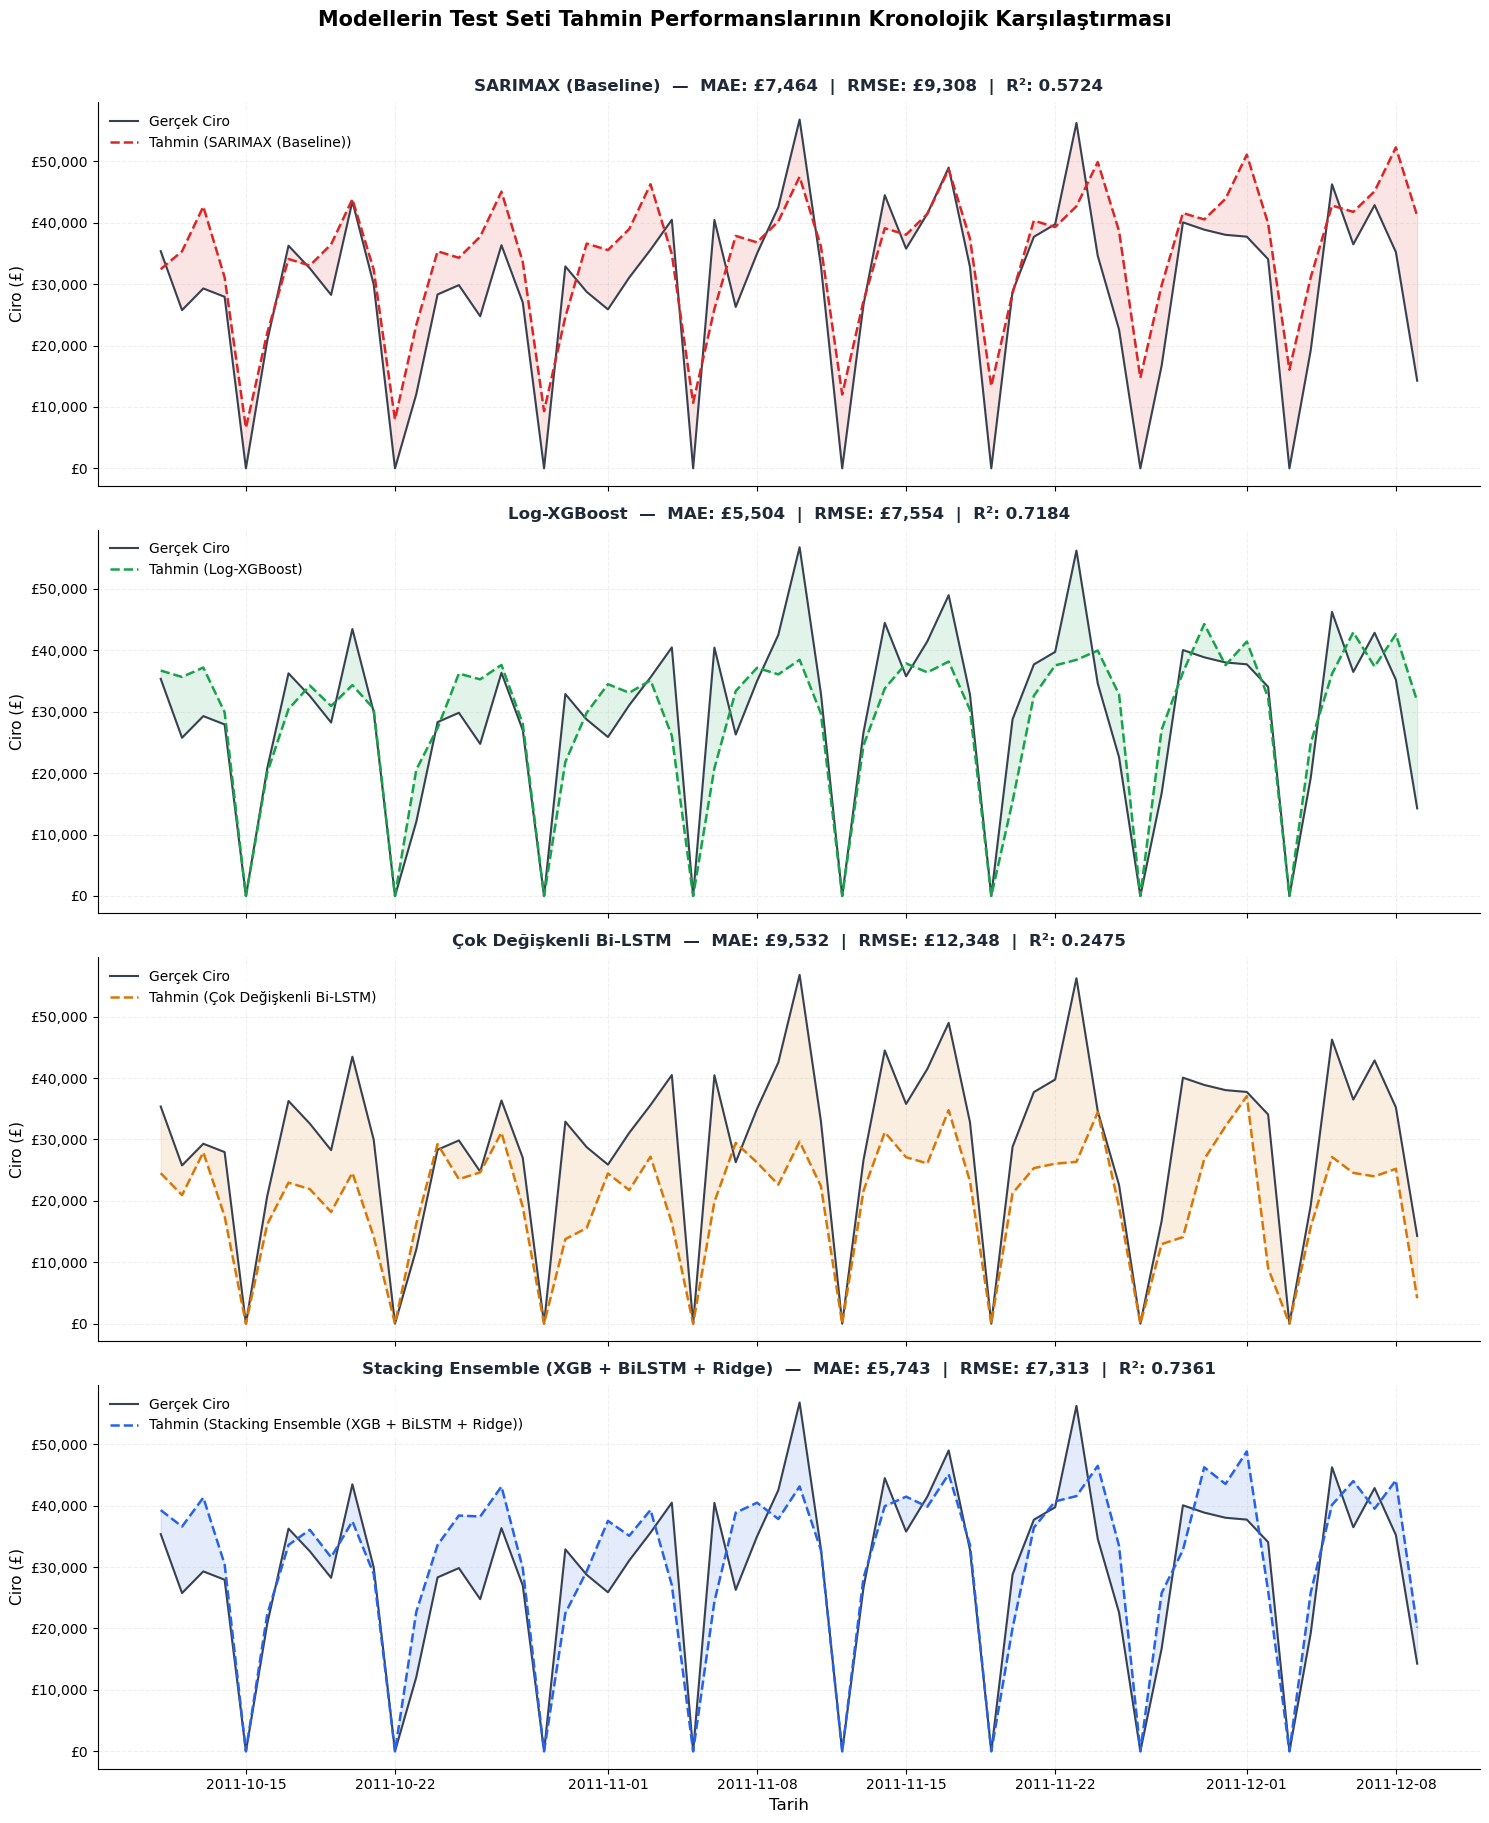

In [46]:
modeller_listesi = [
    ('SARIMAX (Baseline)',                          sarimax_pred_h, PALETTE[2]),
    ('Log-XGBoost',                                xgb_pred_h,     PALETTE[1]),
    ('Çok Değişkenli Bi-LSTM',                     lstm_pred_h,    PALETTE[3]),
    ('Stacking Ensemble (XGB + BiLSTM + Ridge)',   hybrid_pred,    PALETTE[0]),
]
 
fig, axes = plt.subplots(4, 1, figsize=(15, 18), sharex=True)
 
for ax, (name, pred, color) in zip(axes, modeller_listesi):
    ax.plot(test_tarihleri, y_test_hizali_h,
            color='#374151', linewidth=1.5, label='Gerçek Ciro')
    ax.plot(test_tarihleri, pred,
            color=color, linewidth=1.8, linestyle='--', label=f'Tahmin ({name})')
    ax.fill_between(test_tarihleri, y_test_hizali_h, pred,
                    alpha=0.12, color=color)
    ax.set_ylabel('Ciro (£)', fontsize=11)
    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}')
    )
    ax.legend(loc='upper left', frameon=True, facecolor='white',
              edgecolor='none', fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.2)
 
    m_mae  = mean_absolute_error(y_test_hizali_h, pred)
    m_rmse = np.sqrt(mean_squared_error(y_test_hizali_h, pred))
    m_r2   = r2_score(y_test_hizali_h, pred)
    ax.set_title(
        f'{name}  —  MAE: £{m_mae:,.0f}  |  RMSE: £{m_rmse:,.0f}  |  R²: {m_r2:.4f}',
        fontsize=12, pad=8, fontweight='bold', color='#1F2937'
    )
 
plt.suptitle(
    'Modellerin Test Seti Tahmin Performanslarının Kronolojik Karşılaştırması',
    fontsize=15, y=1.01, fontweight='bold'
)
plt.xlabel('Tarih', fontsize=12)
plt.tight_layout()
plt.savefig('grafik10_model_karsilastirma.png', dpi=150, bbox_inches='tight')
plt.show()

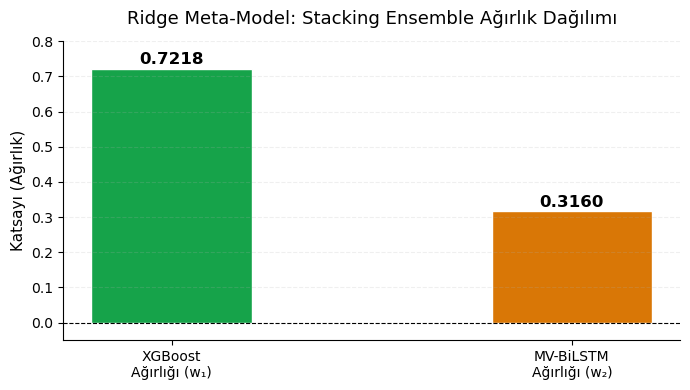


Ridge Intercept: -0.201458
Ağırlıklar normalize edilmemiştir — log uzayında çalışır, toplamaları ≈ 1 olması beklenir.


In [48]:
 
fig, ax = plt.subplots(figsize=(7, 4))
agirlik_etiketleri = ['XGBoost\nAğırlığı (w₁)', 'MV-BiLSTM\nAğırlığı (w₂)']
agirlik_degerleri  = meta_model.coef_
 
renkler = [PALETTE[1], PALETTE[3]]
bars = ax.bar(agirlik_etiketleri, agirlik_degerleri,
              color=renkler, edgecolor='white', width=0.4)
 
for bar, val in zip(bars, agirlik_degerleri):
    ax.text(bar.get_x() + bar.get_width() / 2,
            val + 0.005,
            f'{val:.4f}',
            ha='center', va='bottom', fontsize=12, fontweight='bold')
 
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Ridge Meta-Model: Stacking Ensemble Ağırlık Dağılımı', fontsize=13, pad=12)
ax.set_ylabel('Katsayı (Ağırlık)', fontsize=11)
ax.set_ylim(min(0, agirlik_degerleri.min()) - 0.05,
            agirlik_degerleri.max() + 0.08)
ax.grid(True, linestyle='--', alpha=0.2, axis='y')
 
plt.tight_layout()
plt.savefig('grafik13_stacking_agirliklar.png', dpi=150, bbox_inches='tight')
plt.show()
 
print(f"\nRidge Intercept: {meta_model.intercept_:.6f}")
print("Ağırlıklar normalize edilmemiştir — log uzayında çalışır, toplamaları ≈ 1 olması beklenir.")

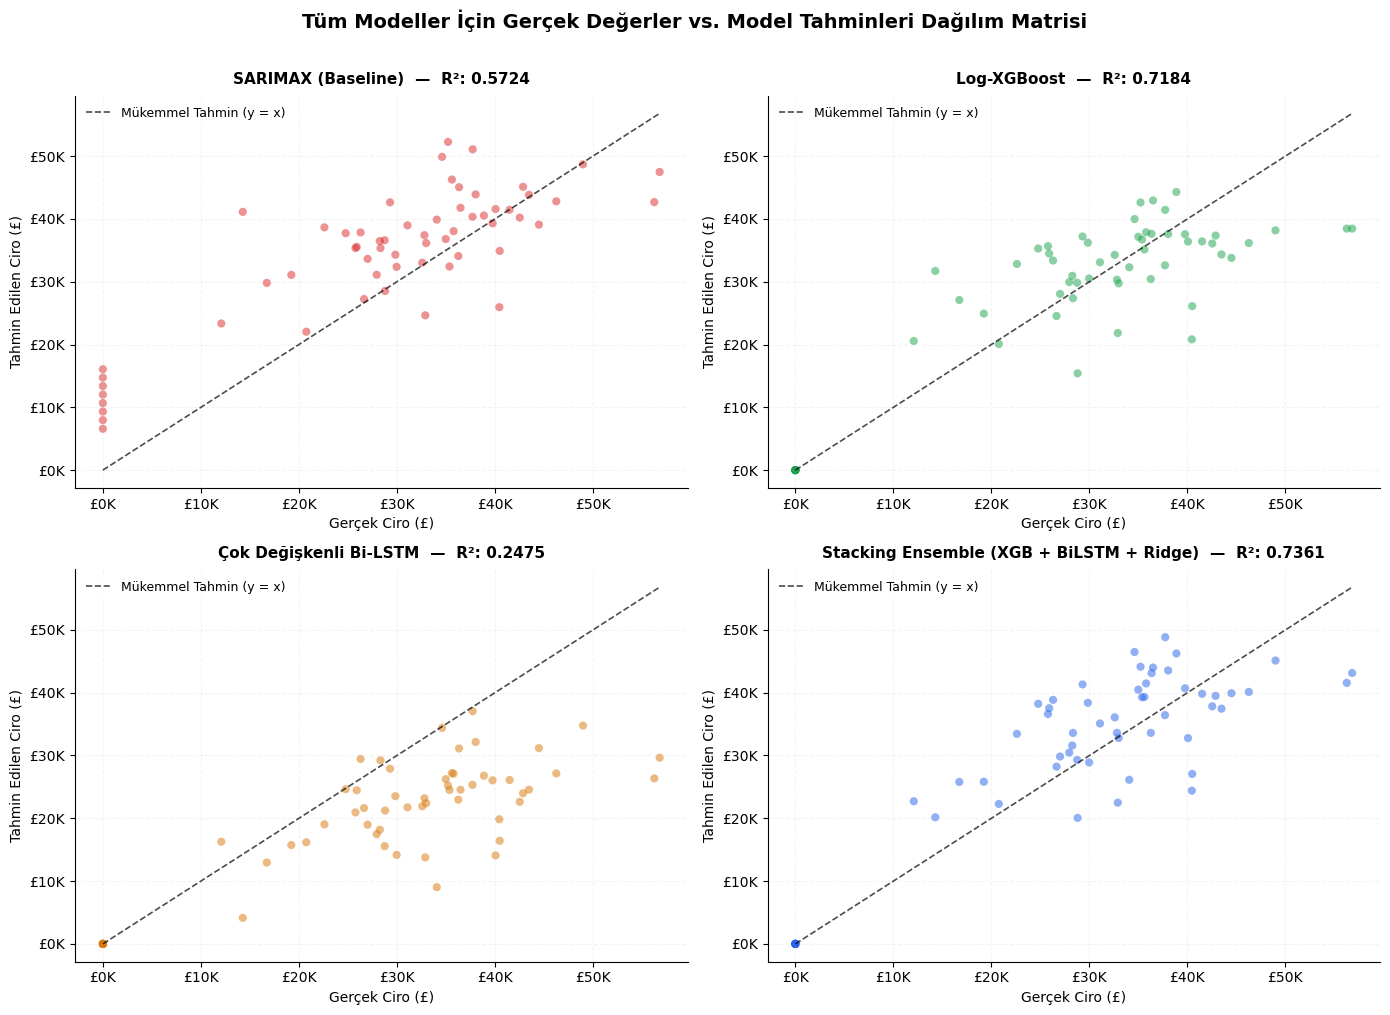

In [49]:
 
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
 
for ax, (name, pred, color) in zip(axes, modeller_listesi):
    ax.scatter(y_test_hizali_h, pred,
               alpha=0.5, s=35, color=color, edgecolors='none')
 
    sınır = [min(y_test_hizali_h.min(), pred.min()),
             max(y_test_hizali_h.max(), pred.max())]
    ax.plot(sınır, sınır, 'k--', linewidth=1.2, alpha=0.7,
            label='Mükemmel Tahmin (y = x)')
 
    m_r2 = r2_score(y_test_hizali_h, pred)
    ax.set_title(f'{name}  —  R²: {m_r2:.4f}',
                 fontsize=11, fontweight='bold', pad=8)
    ax.set_xlabel('Gerçek Ciro (£)', fontsize=10)
    ax.set_ylabel('Tahmin Edilen Ciro (£)', fontsize=10)
    ax.xaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f'£{x/1000:.0f}K')
    )
    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f'£{x/1000:.0f}K')
    )
    ax.legend(loc='upper left', fontsize=9, frameon=True,
              facecolor='white', edgecolor='none')
    ax.grid(True, linestyle='--', alpha=0.15)
 
plt.suptitle(
    'Tüm Modeller İçin Gerçek Değerler vs. Model Tahminleri Dağılım Matrisi',
    fontsize=14, y=1.01, fontweight='bold'
)
plt.tight_layout()
plt.savefig('grafik12_scatter_analizi.png', dpi=150, bbox_inches='tight')
plt.show()

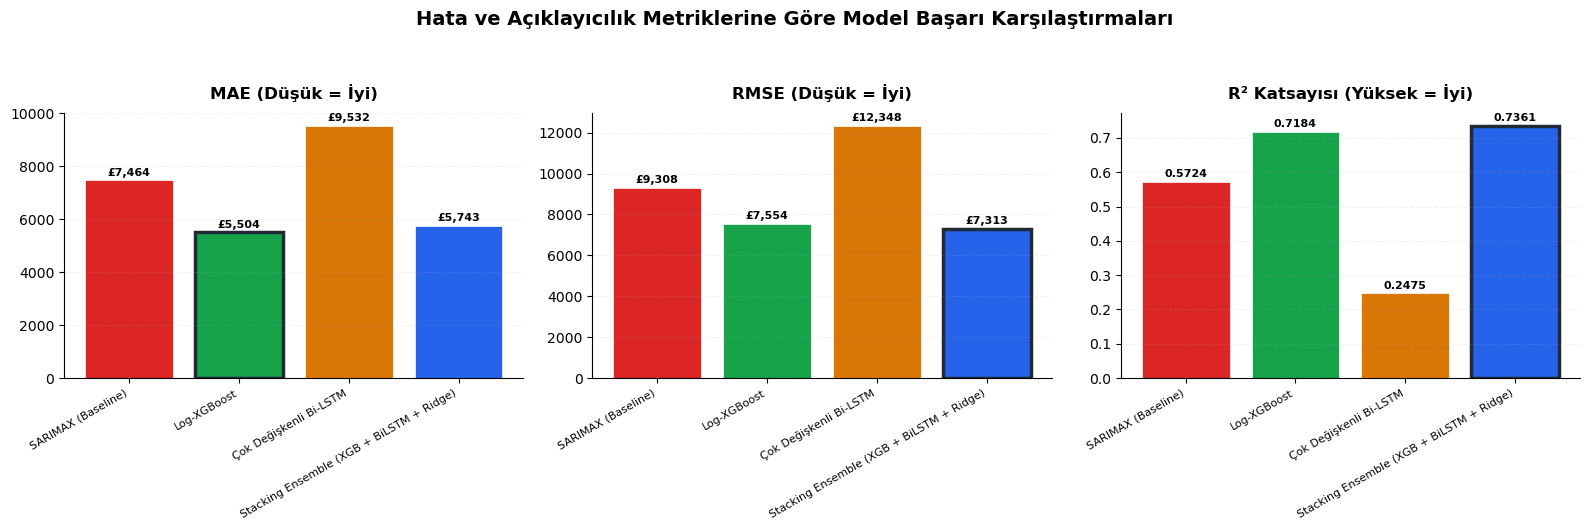

In [50]:
# ─────────────────────────────────────────────────────────────────────────────
 
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
model_etiketleri = performans_tablosu['Model Mimarisi'].tolist()
bar_renkleri     = [PALETTE[2], PALETTE[1], PALETTE[3], PALETTE[0]]
metrikler = [
    ('MAE (£)',  'MAE (Düşük = İyi)'),
    ('RMSE (£)', 'RMSE (Düşük = İyi)'),
    ('R² Skoru', 'R² Katsayısı (Yüksek = İyi)')
]
 
for i, (sutun_adi, baslik) in enumerate(metrikler):
    ax       = axes[i]
    degerler = performans_tablosu[sutun_adi].tolist()
    bars     = ax.bar(model_etiketleri, degerler,
                      color=bar_renkleri, edgecolor='white', linewidth=0.5)
 
    en_iyi = (degerler.index(max(degerler))
              if sutun_adi == 'R² Skoru'
              else degerler.index(min(degerler)))
    bars[en_iyi].set_edgecolor('#1F2937')
    bars[en_iyi].set_linewidth(2.5)
 
    for bar in bars:
        h = bar.get_height()
        etiket = f'{h:.4f}' if sutun_adi == 'R² Skoru' else f'£{h:,.0f}'
        ax.text(bar.get_x() + bar.get_width() / 2,
                h + max(degerler) * 0.01,
                etiket, ha='center', va='bottom',
                fontsize=8, fontweight='bold')
 
    ax.set_title(baslik, fontsize=12, pad=10, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.15, axis='y')
    ax.set_xticklabels(model_etiketleri, rotation=30, ha='right', fontsize=8)
 
plt.suptitle(
    'Hata ve Açıklayıcılık Metriklerine Göre Model Başarı Karşılaştırmaları',
    fontsize=14, y=1.05, fontweight='bold'
)
plt.tight_layout()
plt.savefig('grafik11_metrik_karsilastirma.png', dpi=150, bbox_inches='tight')
plt.show()

In [47]:
print("\n" + "="*75)
print("     BİLECİK ŞEYH EDEBALİ ÜNİVERSİTESİ — LİSANS TEZ ÇALIŞMASI")
print("          E-TİCARET TALEP TAHMİN SİSTEMİ PROJE NİHAİ RAPORU")
print("="*75)
print(f" Toplam İşlenen Ham Kayıt Satırı  : {data.shape[0]:>12,}")
print(f" Kesintisiz Zaman Serisi Boyutu   : {len(daily):>12} gün")
print(f" Model Eğitim / Test Bölünmesi    : {len(X_train):>6} Gün Eğitim / {TEST_SIZE} Gün Test")
print(f" Özellik (Feature) Sayısı         : {len(ozellik_sutunlari):>12}")
print(f" LSTM Lookback Penceresi           : {LOOKBACK:>12} gün")
print(f" ABC Analizi Lokomotif Ürün Sayısı: {(product_revenue['ABC']=='A').sum():>12,} Ürün (A Sınıfı)")
print("-"*75)
print(performans_tablosu.to_string(index=False))
print("-"*75)
print(f" Şampiyon Model                   : {en_iyi_model_adi}")
print(f" Elde Edilen En Yüksek R²          : {performans_tablosu['R² Skoru'].max():.4f}")
print(f" Elde Edilen En Düşük MAE          : £{performans_tablosu['MAE (£)'].min():>12,.2f}")
print("="*75)
print("Proje tüm fazlarıyla sıfır hatayla tamamlanmıştır. Jüri sunumuna hazırdır. ✓")
 


     BİLECİK ŞEYH EDEBALİ ÜNİVERSİTESİ — LİSANS TEZ ÇALIŞMASI
          E-TİCARET TALEP TAHMİN SİSTEMİ PROJE NİHAİ RAPORU
 Toplam İşlenen Ham Kayıt Satırı  :      805,549
 Kesintisiz Zaman Serisi Boyutu   :          739 gün
 Model Eğitim / Test Bölünmesi    :    651 Gün Eğitim / 60 Gün Test
 Özellik (Feature) Sayısı         :           38
 LSTM Lookback Penceresi           :           21 gün
 ABC Analizi Lokomotif Ürün Sayısı:        1,043 Ürün (A Sınıfı)
---------------------------------------------------------------------------
                          Model Mimarisi  MAE (£)  RMSE (£)  R² Skoru
                      SARIMAX (Baseline)  7464.17   9307.79    0.5724
                             Log-XGBoost  5504.07   7554.00    0.7184
                  Çok Değişkenli Bi-LSTM  9532.50  12348.22    0.2475
Stacking Ensemble (XGB + BiLSTM + Ridge)  5743.18   7312.65    0.7361
---------------------------------------------------------------------------
 Şampiyon Model                   : S